# Imports

In [1]:
import json
import time

import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt

from pathlib import Path
from matplotlib.patches import Rectangle
from sklearn.preprocessing import LabelEncoder
from sklearn.datasets import make_classification
from sklearn.metrics import classification_report
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# General Information

In [2]:
%%time

data_dir = Path("data/")
csv_files = sorted(data_dir.glob("*.csv"))

df = pd.concat((pd.read_csv(file) for file in csv_files), ignore_index=True)

CPU times: user 1min 23s, sys: 5.3 s, total: 1min 28s
Wall time: 1min 41s


In [3]:
df.shape

(16232943, 80)

In [4]:
print(f"Number of Rows (Samples): {df.shape[0]}")
print(f"Number of Columns (Features): {df.shape[1]}")

Number of Rows (Samples): 16232943
Number of Columns (Features): 80


In [5]:
df.head()

,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,443,6,02/03/2018 08:47:38,141385,9,7,553.0,3773.0,202.0,0.0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
1,49684,6,02/03/2018 08:47:38,281,2,1,38.0,0.0,38.0,0.0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
2,443,6,02/03/2018 08:47:40,279824,11,15,1086.0,10527.0,385.0,0.0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
3,443,6,02/03/2018 08:47:40,132,2,0,0.0,0.0,0.0,0.0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
4,443,6,02/03/2018 08:47:41,274016,9,13,1285.0,6141.0,517.0,0.0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign


In [6]:
df.columns

Index(['Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts',
       'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
       'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
       'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
       'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
       'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s',
       'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean',
       'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt',
       'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt',
       'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg',
      

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16232943 entries, 0 to 16232942
Data columns (total 80 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Dst Port           int64  
 1   Protocol           int64  
 2   Timestamp          str    
 3   Flow Duration      int64  
 4   Tot Fwd Pkts       int64  
 5   Tot Bwd Pkts       int64  
 6   TotLen Fwd Pkts    float64
 7   TotLen Bwd Pkts    float64
 8   Fwd Pkt Len Max    float64
 9   Fwd Pkt Len Min    float64
 10  Fwd Pkt Len Mean   float64
 11  Fwd Pkt Len Std    float64
 12  Bwd Pkt Len Max    float64
 13  Bwd Pkt Len Min    float64
 14  Bwd Pkt Len Mean   float64
 15  Bwd Pkt Len Std    float64
 16  Flow Byts/s        float64
 17  Flow Pkts/s        float64
 18  Flow IAT Mean      float64
 19  Flow IAT Std       float64
 20  Flow IAT Max       float64
 21  Flow IAT Min       float64
 22  Fwd IAT Tot        float64
 23  Fwd IAT Mean       float64
 24  Fwd IAT Std        float64
 25  Fwd IAT Max        float64


Create new column with shorthand labels and map them to original labels

In [8]:
df['Label'].value_counts()

Label
Benign                      13484708
DDOS attack-HOIC              686012
DDoS attacks-LOIC-HTTP        576191
DoS attacks-Hulk              461912
Bot                           286191
FTP-BruteForce                193360
SSH-Bruteforce                187589
Infilteration                 161934
DoS attacks-SlowHTTPTest      139890
DoS attacks-GoldenEye          41508
DoS attacks-Slowloris          10990
DDOS attack-LOIC-UDP            1730
Brute Force -Web                 611
Brute Force -XSS                 230
SQL Injection                     87
Name: count, dtype: int64

In [9]:
df['Label'].unique()

<StringArray>
[                  'Benign',                      'Bot',
 'DoS attacks-SlowHTTPTest',         'DoS attacks-Hulk',
         'Brute Force -Web',         'Brute Force -XSS',
            'SQL Injection',   'DDoS attacks-LOIC-HTTP',
            'Infilteration',    'DoS attacks-GoldenEye',
    'DoS attacks-Slowloris',           'FTP-BruteForce',
           'SSH-Bruteforce',     'DDOS attack-LOIC-UDP',
         'DDOS attack-HOIC']
Length: 15, dtype: str

In [10]:
label_map = {
    'Benign': 'Benign',
    'Bot': 'Bot',
    'DoS attacks-SlowHTTPTest': 'SlowHTTPTest',
    'DoS attacks-Hulk': 'Hulk',
    'Brute Force -Web': 'Web',
    'Brute Force -XSS': 'XSS',
    'SQL Injection': 'SQL',
    'DDoS attacks-LOIC-HTTP': 'LOIC_HTTP',
    'Infilteration': 'Infiltration',   # note: original dataset misspells this
    'DoS attacks-GoldenEye': 'GoldenEye',
    'DoS attacks-Slowloris': 'Slowloris',
    'FTP-BruteForce': 'FTP',
    'SSH-Bruteforce': 'SSH',
    'DDOS attack-LOIC-UDP': 'LOIC_UDP',
    'DDOS attack-HOIC': 'HOIC',
}

df['Label_Short'] = df['Label'].map(label_map)

In [11]:
assert df['Label_Short'].isna().sum() == 0, "Unmapped labels found!"

In [12]:
unmatched = df.loc[df['Label_Short'].isna(), 'Label'].unique()

print(f"Number of unmatched labels: {len(unmatched)}")

Number of unmatched labels: 0


# Plots

## Log Scale

Show class distribution in this dataset

In [13]:
def log_scale(plot_data, title, xlabel, ylabel):
    """Draw a class distribution log scale from provided plot_data"""
    x, y = [[] for z in range(2)]
    for i in plot_data.index:
        x.append(i)
        y.append(plot_data[i])
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.grid(
        True,
        alpha=0.3
    )
    ax.set_yscale("log")  # Convert y-axis to logarithmic scale
    ax.plot(
        x,
        y,
        "o-",
        color="green"
    )
    ax.set_xlabel(f"{xlabel}")
    ax.set_ylabel(f"{ylabel}")
    fig.tight_layout()
    plt.xticks(rotation=90)
    plt.title(
        f"{title}",
        fontsize = 16,
        fontweight="bold"
    )
    plt.show()
    fig.savefig(
        f"images/{title}.png",
        bbox_inches="tight"
    )
    fig.clear()
    plt.close(fig)

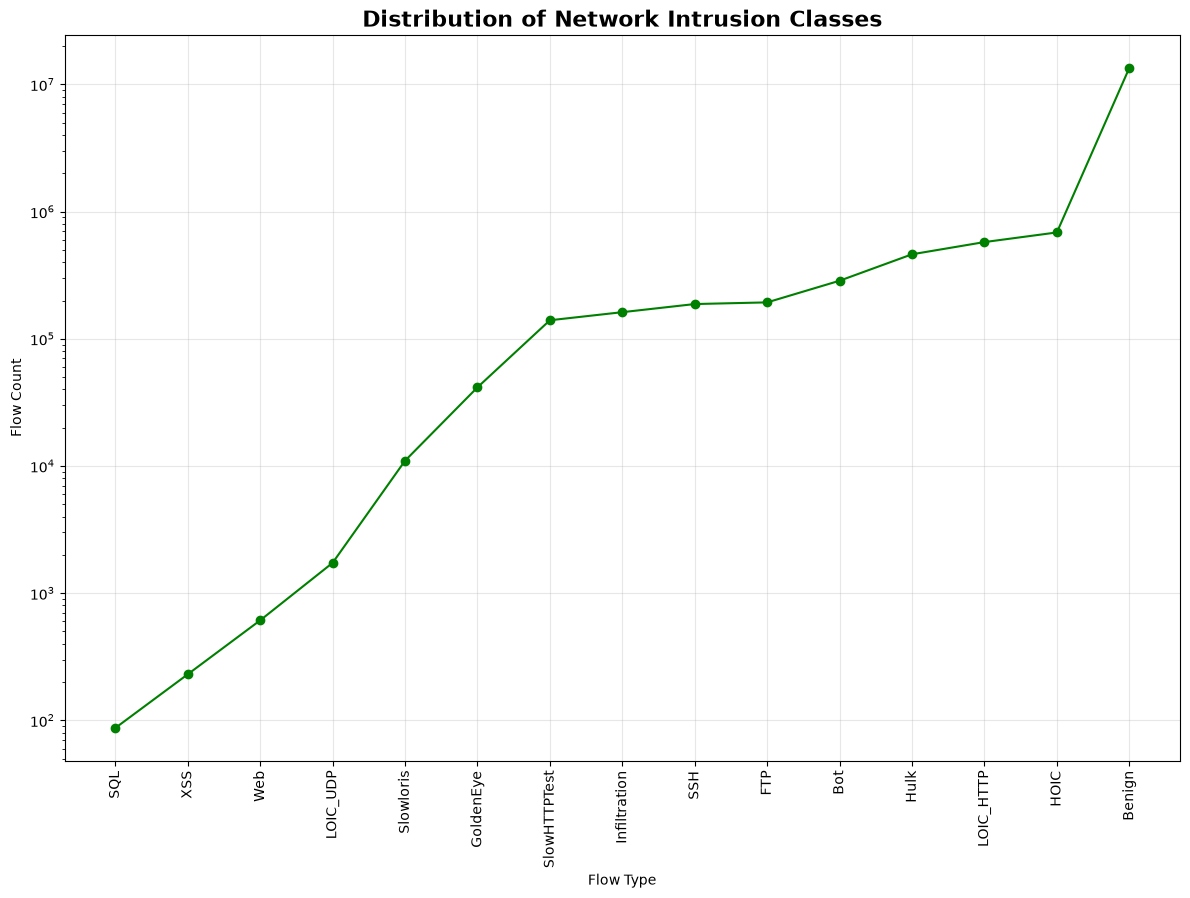

CPU times: user 1.82 s, sys: 19.2 ms, total: 1.83 s
Wall time: 1.94 s


In [14]:
%%time

plot_data = df['Label_Short'].value_counts(ascending=True)

log_scale(
    plot_data,
    "Distribution of Network Intrusion Classes",
    "Flow Type",
    "Flow Count"
)

## Pie Chart

Show ratio between Benign and Malicious flows, available in CSE-CIC-IDS2018

In [15]:
def format_class_data(df, count = 0):
    """Format dataframe into binary classification of benign and malicious"""
    for x in df.index:
        if x != "Benign":
            count += df[x]

    labels = ["Benign", "Malicious"]
    values = [df["Benign"], count]

    return labels, values

In [16]:
def pie_plot(labels, values, title):
    """Pie plot to show benign vs malicious flow record distribution"""
    plt.clf() # Clear canvas before plottting
    fig, ax = plt.subplots(figsize=(10, 5))
    fig.tight_layout()
    plt.title(label=f"{title}", fontsize = 16, fontweight="bold")
    ax.pie(values, labels=labels, autopct='%1.0f%%',
           wedgeprops = {"edgecolor": "black",
                         "linewidth": 1,
                         "antialiased": True})
    ax.legend()
    fig.savefig(f"images/{title}.png", bbox_inches="tight")

CPU times: user 1.19 s, sys: 6.1 ms, total: 1.2 s
Wall time: 1.22 s


<Figure size 640x480 with 0 Axes>

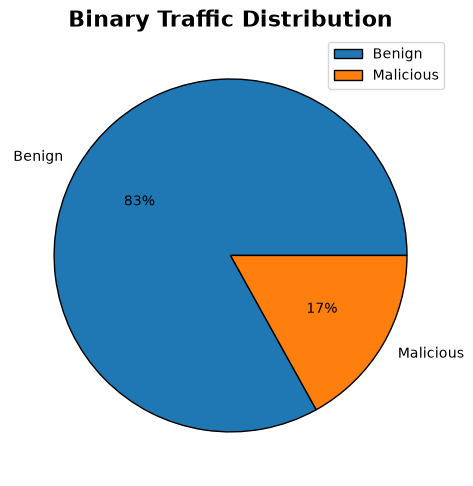

In [17]:
%%time

labels, values = format_class_data(df['Label_Short'].value_counts())

pie_plot(
    labels,
    values,
    "Binary Traffic Distribution"
)

## Protocol Chart

Chart of network protocols for which the flows are initiated

0 - protocol not assigned (possibly ICMP)<br/>
6 - TCP<br/>
17 - UDP

In [18]:
df['Protocol'].unique()

array([ 6,  0, 17])

In [19]:
df['Protocol'].value_counts()

Protocol
6     11800335
17     4194295
0       238313
Name: count, dtype: int64

In [20]:
def format_protocol_data(df, labels = [], values = []):
    """Format dataframe into binary classification of benign and malicious"""
    for x in df.index:
        if x == 0:
            labels.append("Unassigned")
        elif x == 6:
            labels.append("TCP")
        elif x == 17:
            labels.append("UDP")
        values.append(df[x])

    return labels, values

CPU times: user 160 ms, sys: 2.88 ms, total: 163 ms
Wall time: 161 ms


<Figure size 640x480 with 0 Axes>

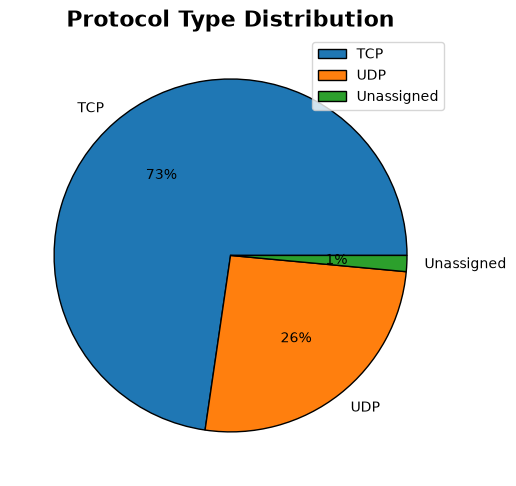

In [21]:
%%time

labels, values = format_protocol_data(df['Protocol'].value_counts())

pie_plot(
    labels,
    values,
    "Protocol Type Distribution"
)

# Cleaning Data

Objectives include:
1. Delete session info (Dst Port, Timestamp).
2. Delete rows with columns containing Infinity / NaN values.
3. Remove duplicated rows.

## Delete Session Info

Delete columns that have session info of flow data collection (Dst Port, Timestamp)

In [22]:
print(f"Column count before deletion: {len(df.columns)}")

Column count before deletion: 81


In [23]:
%%time

df.drop(['Dst Port', 'Timestamp'], axis=1, inplace=True)

CPU times: user 125 ms, sys: 7.97 ms, total: 133 ms
Wall time: 133 ms


In [24]:
print(f"Column count after deletion: {len(df.columns)}")

Column count after deletion: 79


## Dealing With Missing Values

Analyze the dataset for rows that contain NaN or Infinity values

In [25]:
%%time

nan_values = {key: value for key, value in df.isna().sum().items() if value > 0}

print(nan_values)

{'Flow Byts/s': 59721}
CPU times: user 1.99 s, sys: 2.1 ms, total: 1.99 s
Wall time: 1.99 s


Filter for infinity values and replace them as NaN

In [26]:
%%time

df.replace([np.inf, -np.inf], np.nan, inplace=True)

CPU times: user 2.53 s, sys: 7.27 s, total: 9.8 s
Wall time: 9.89 s


,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,Fwd Pkt Len Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Label_Short
0,6,141385,9,7,553.0,3773.0,202.0,0.0,61.444444,87.534438,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,Benign
1,6,281,2,1,38.0,0.0,38.0,0.0,19.000000,26.870058,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,Benign
2,6,279824,11,15,1086.0,10527.0,385.0,0.0,98.727273,129.392497,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,Benign
3,6,132,2,0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,Benign
4,6,274016,9,13,1285.0,6141.0,517.0,0.0,142.777778,183.887722,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,Benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16232938,6,3,1,1,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Infilteration,Infiltration
16232939,6,2,1,1,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Infilteration,Infiltration
16232940,6,732728,2,2,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,Benign
16232941,6,22,1,1,0.0,0.0,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Infilteration,Infiltration


Updated list of NaN values

In [27]:
%%time

nan_values = {key: value for key, value in df.isna().sum().items() if value > 0}

print(nan_values)

{'Flow Byts/s': 95760, 'Flow Pkts/s': 95760}
CPU times: user 2.02 s, sys: 36.3 ms, total: 2.05 s
Wall time: 2.05 s


Create a bar plot to visualize NaN data

In [28]:
def nan_plot(_dict, title, xlabel, ylabel):
    """Bar plot for NaN values"""
    bar_labels = [_dict['Flow Byts/s'], _dict['Flow Pkts/s']]

    fig, ax = plt.subplots(figsize=(10,10))
    ax.grid(
        True,
        alpha=0.3
    )
    ax.bar(
        _dict.keys(),
        _dict.values(),
        zorder=3
    )
    for container in ax.containers:
        ax.bar_label(container, labels=bar_labels)
    ax.set_title(
        f"{title}",
        fontsize=16,
        fontweight="bold"
    )
    ax.set_xlabel(f"{xlabel}")
    ax.set_ylabel(f"{ylabel}")
    fig.savefig(
        f"images/{title}.png",
        bbox_inches="tight"
    )

CPU times: user 106 ms, sys: 22.5 ms, total: 129 ms
Wall time: 162 ms


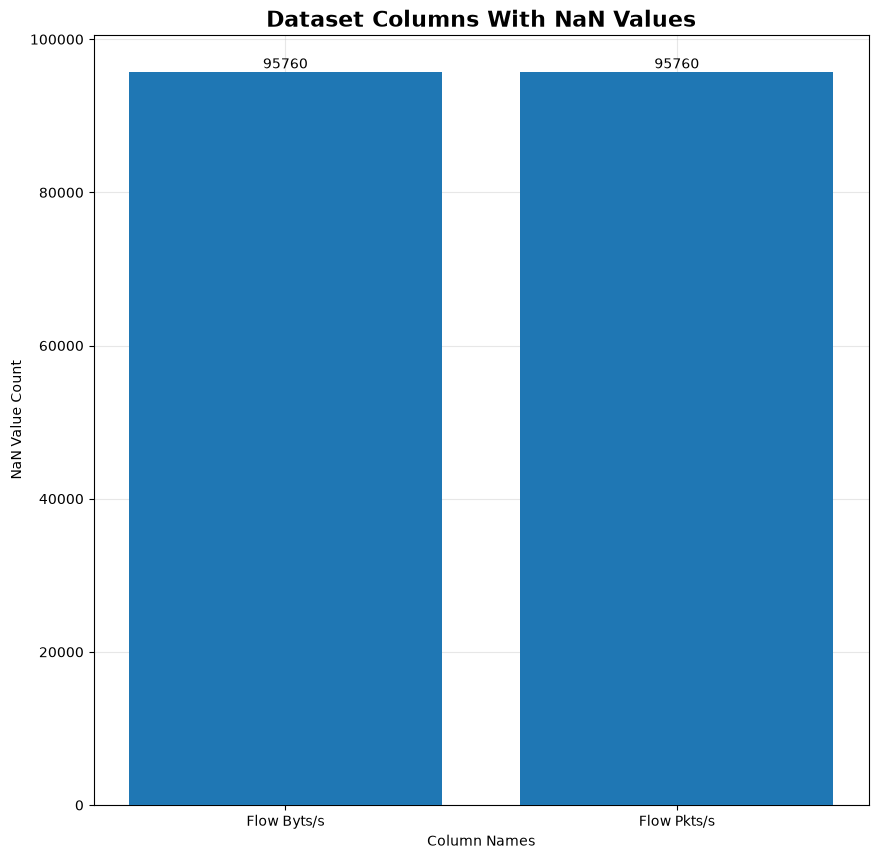

In [29]:
%%time

nan_plot(
    nan_values,
    "Dataset Columns With NaN Values",
    "Column Names",
    "NaN Value Count"
)

Delete rows that contain NaN values

In [30]:
%%time

before = {x: df['Label'].value_counts()[x] for x in df['Label'].value_counts().index}

CPU times: user 20.7 s, sys: 13.4 ms, total: 20.7 s
Wall time: 20.8 s


In [31]:
%%time

df.dropna(inplace=True)
df = df.reset_index(drop=True)

CPU times: user 3.29 s, sys: 514 ms, total: 3.81 s
Wall time: 3.87 s


In [32]:
%%time

after = {x: df['Label'].value_counts()[x] for x in df['Label'].value_counts().index}

CPU times: user 21.1 s, sys: 19.8 ms, total: 21.1 s
Wall time: 21.2 s


In [33]:
total = 0
for (k, v), (k2, v2) in zip(before.items(), after.items()):
    print(f"{k} has {v - v2} rows dropped")
    total += v - v2
print(f"Total rows dropped: {total}")

Benign has 94459 rows dropped
DDOS attack-HOIC has 0 rows dropped
DDoS attacks-LOIC-HTTP has 0 rows dropped
DoS attacks-Hulk has 0 rows dropped
Bot has 0 rows dropped
FTP-BruteForce has 6 rows dropped
SSH-Bruteforce has 0 rows dropped
Infilteration has 1295 rows dropped
DoS attacks-SlowHTTPTest has 0 rows dropped
DoS attacks-GoldenEye has 0 rows dropped
DoS attacks-Slowloris has 0 rows dropped
DDOS attack-LOIC-UDP has 0 rows dropped
Brute Force -Web has 0 rows dropped
Brute Force -XSS has 0 rows dropped
SQL Injection has 0 rows dropped
Total rows dropped: 95760


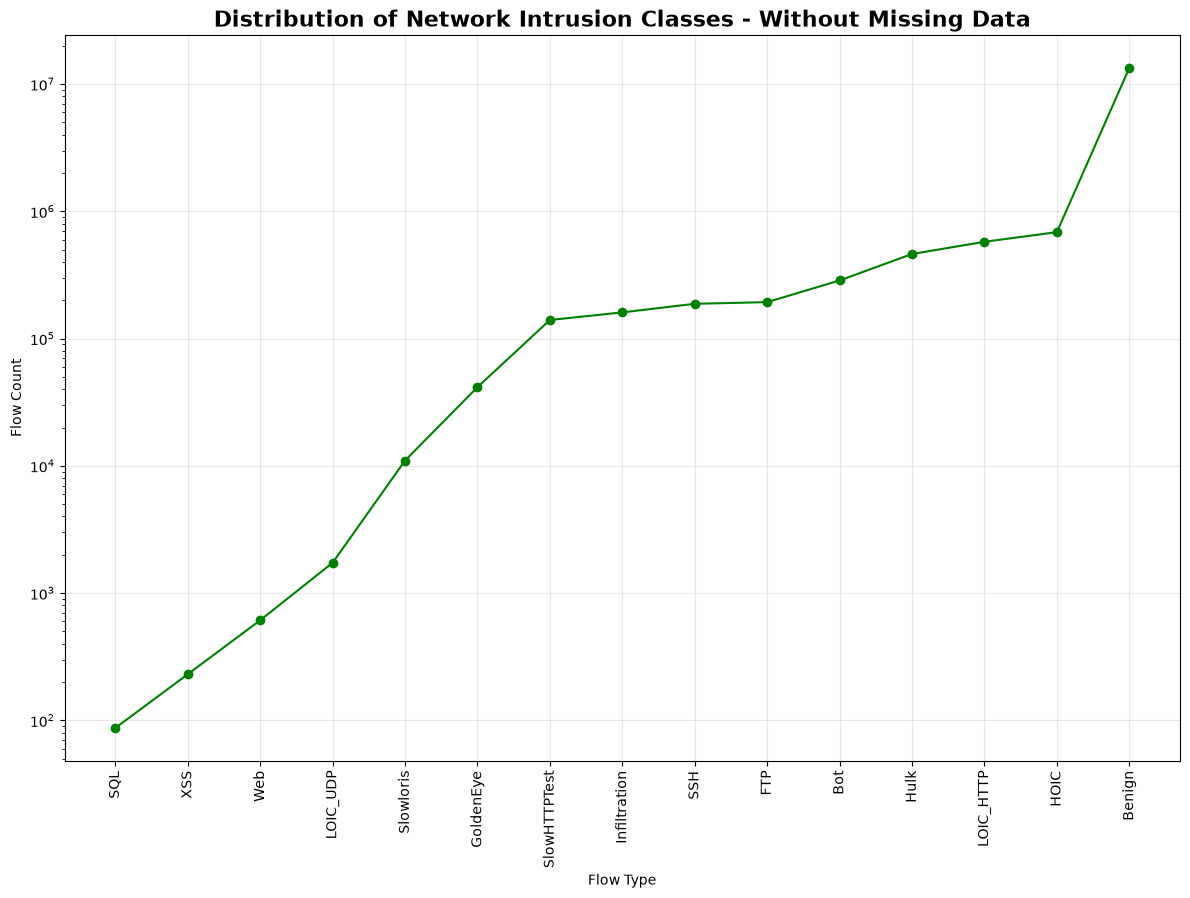

CPU times: user 1.69 s, sys: 21.2 ms, total: 1.71 s
Wall time: 1.76 s


In [34]:
%%time

plot_data = df['Label_Short'].value_counts(ascending=True)

log_scale(
    plot_data,
    "Distribution of Network Intrusion Classes - Without Missing Data",
    "Flow Type",
    "Flow Count"
)

## Drop Duplicates

In [35]:
%%time

before = {x: df['Label'].value_counts()[x] for x in df['Label'].value_counts().index}

CPU times: user 21 s, sys: 13.5 ms, total: 21 s
Wall time: 21 s


In [36]:
%%time

df.drop_duplicates(inplace=True)
df = df.reset_index(drop=True)

CPU times: user 1min 21s, sys: 2.41 s, total: 1min 23s
Wall time: 1min 24s


In [37]:
%%time

after = {x: df['Label'].value_counts()[x] for x in df['Label'].value_counts().index}

CPU times: user 13.9 s, sys: 10.3 ms, total: 13.9 s
Wall time: 14 s


In [38]:
total = 0
for (k, v), (k2, v2) in zip(before.items(), after.items()):
    print(f"{k} has {v - v2} rows dropped")
    total += v - v2
print(f"Total rows dropped: {total}")

Benign has 3897052 rows dropped
DDOS attack-HOIC has 110648 rows dropped
DDoS attacks-LOIC-HTTP has 377330 rows dropped
DoS attacks-Hulk has 316713 rows dropped
Bot has 141656 rows dropped
FTP-BruteForce has 79535 rows dropped
SSH-Bruteforce has 93541 rows dropped
Infilteration has 119233 rows dropped
DoS attacks-SlowHTTPTest has 129982 rows dropped
DoS attacks-GoldenEye has 39778 rows dropped
DoS attacks-Slowloris has 10435 rows dropped
DDOS attack-LOIC-UDP has 1502 rows dropped
Brute Force -Web has 527 rows dropped
Brute Force -XSS has 175 rows dropped
SQL Injection has 34 rows dropped
Total rows dropped: 5318141


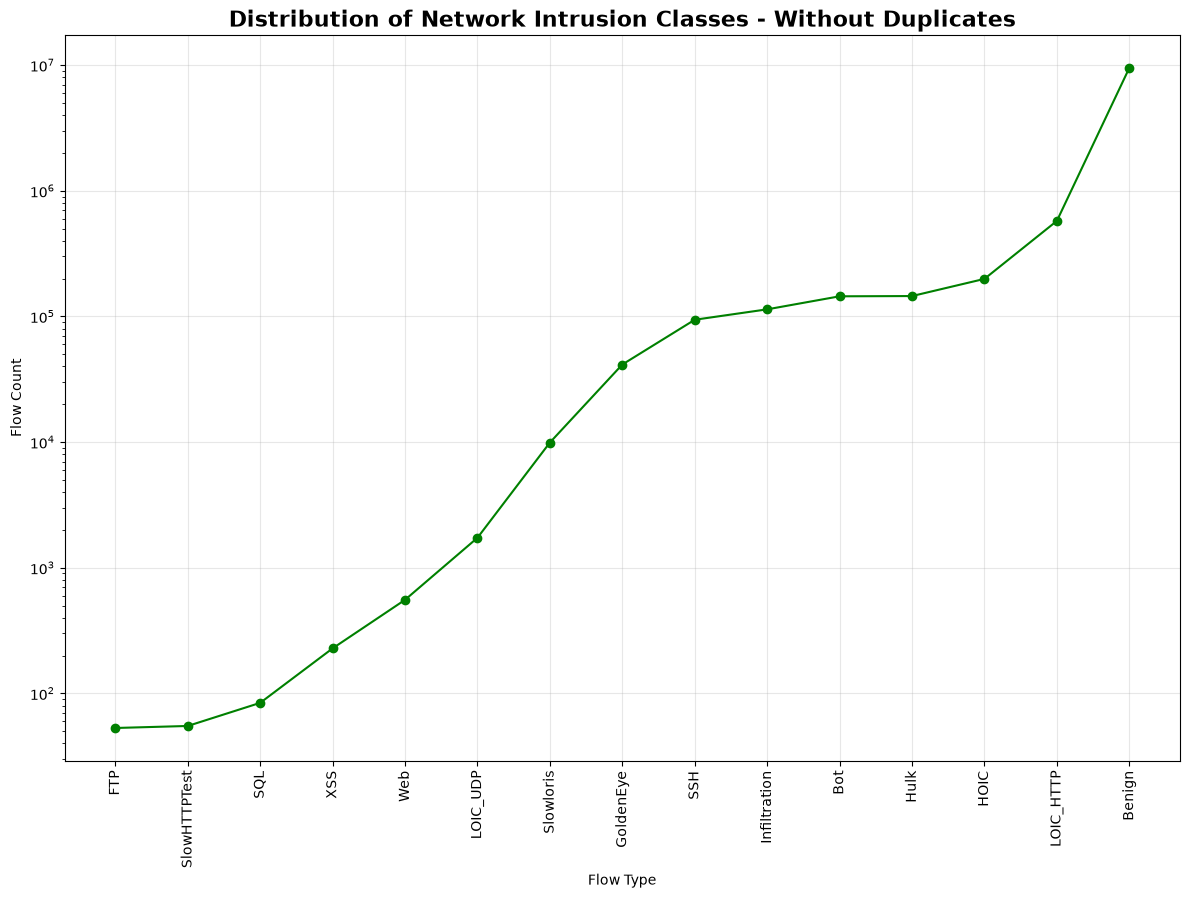

CPU times: user 1.38 s, sys: 17.6 ms, total: 1.4 s
Wall time: 1.41 s


In [39]:
%%time

plot_data = df['Label_Short'].value_counts(ascending=True)

log_scale(
    plot_data,
    "Distribution of Network Intrusion Classes - Without Duplicates",
    "Flow Type",
    "Flow Count"
)

# Feature Selection

Trim features:
1. Split data to train and test dataframes.
2. Remove features with zero variance.
3. Remove highly correlated features.
4. Compute feature importance with XGBoost.

## Train Test Split

In [41]:
start = time.time()
print("Doing a train/test split")
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['Label'],
    random_state=42
)

end = time.time()
print(f"Train/test split finished in {end - start} seconds")

Doing a train/test split
Train/test split finished in 21.58706498146057 seconds


## Zero Variance Columns

Drop features with zero variance

In [42]:
%%time

zero_variance_cols = train_df.columns[train_df.nunique() <= 1]
print(f"Columns with zero variance: {len(zero_variance_cols)}\nColumn names: {zero_variance_cols.tolist()}\nDtype: {zero_variance_cols.dtype}")

Columns with zero variance: 8
Column names: ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg', 'Bwd Byts/b Avg', 'Bwd Pkts/b Avg', 'Bwd Blk Rate Avg']
Dtype: str
CPU times: user 16.8 s, sys: 179 ms, total: 17 s
Wall time: 17.2 s


In [43]:
%%time

train_df.drop(zero_variance_cols, axis=1, inplace=True)

CPU times: user 254 ms, sys: 5.01 s, total: 5.27 s
Wall time: 5.29 s


In [44]:
print(f"Columns left: {len(train_df.columns)}")

Columns left: 71


## Calculate Correlation

Figure out and drop features that are highly correlated (|r| > 0.95) 

In [45]:
%%time

correlation_data = train_df.corr(method='spearman', numeric_only=True)

CPU times: user 5min 18s, sys: 29.8 s, total: 5min 48s
Wall time: 5min 53s


In [46]:
def full_correlation_heatmap(correlation_data, title, columns):
    """Plot a correlation heatmap for all available features"""
    fig, ax = plt.subplots(figsize=(16, 14))

    im = ax.imshow(
        correlation_data,
        vmin=-1,
        vmax=1,
        aspect="equal"
    )

    # Feature names
    ax.set_xticks(np.arange(len(columns)))
    ax.set_yticks(np.arange(len(columns)))

    ax.set_xticklabels(
        columns,
        rotation=90,
        fontsize=8
    )
    ax.set_yticklabels(
        columns,
        fontsize=8
    )

    # Colorbar
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(
        f"Spearman Correlation (ρ)",
        fontsize=12
    )

    ax.set_title(
        f"{title}",
        fontsize=16,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

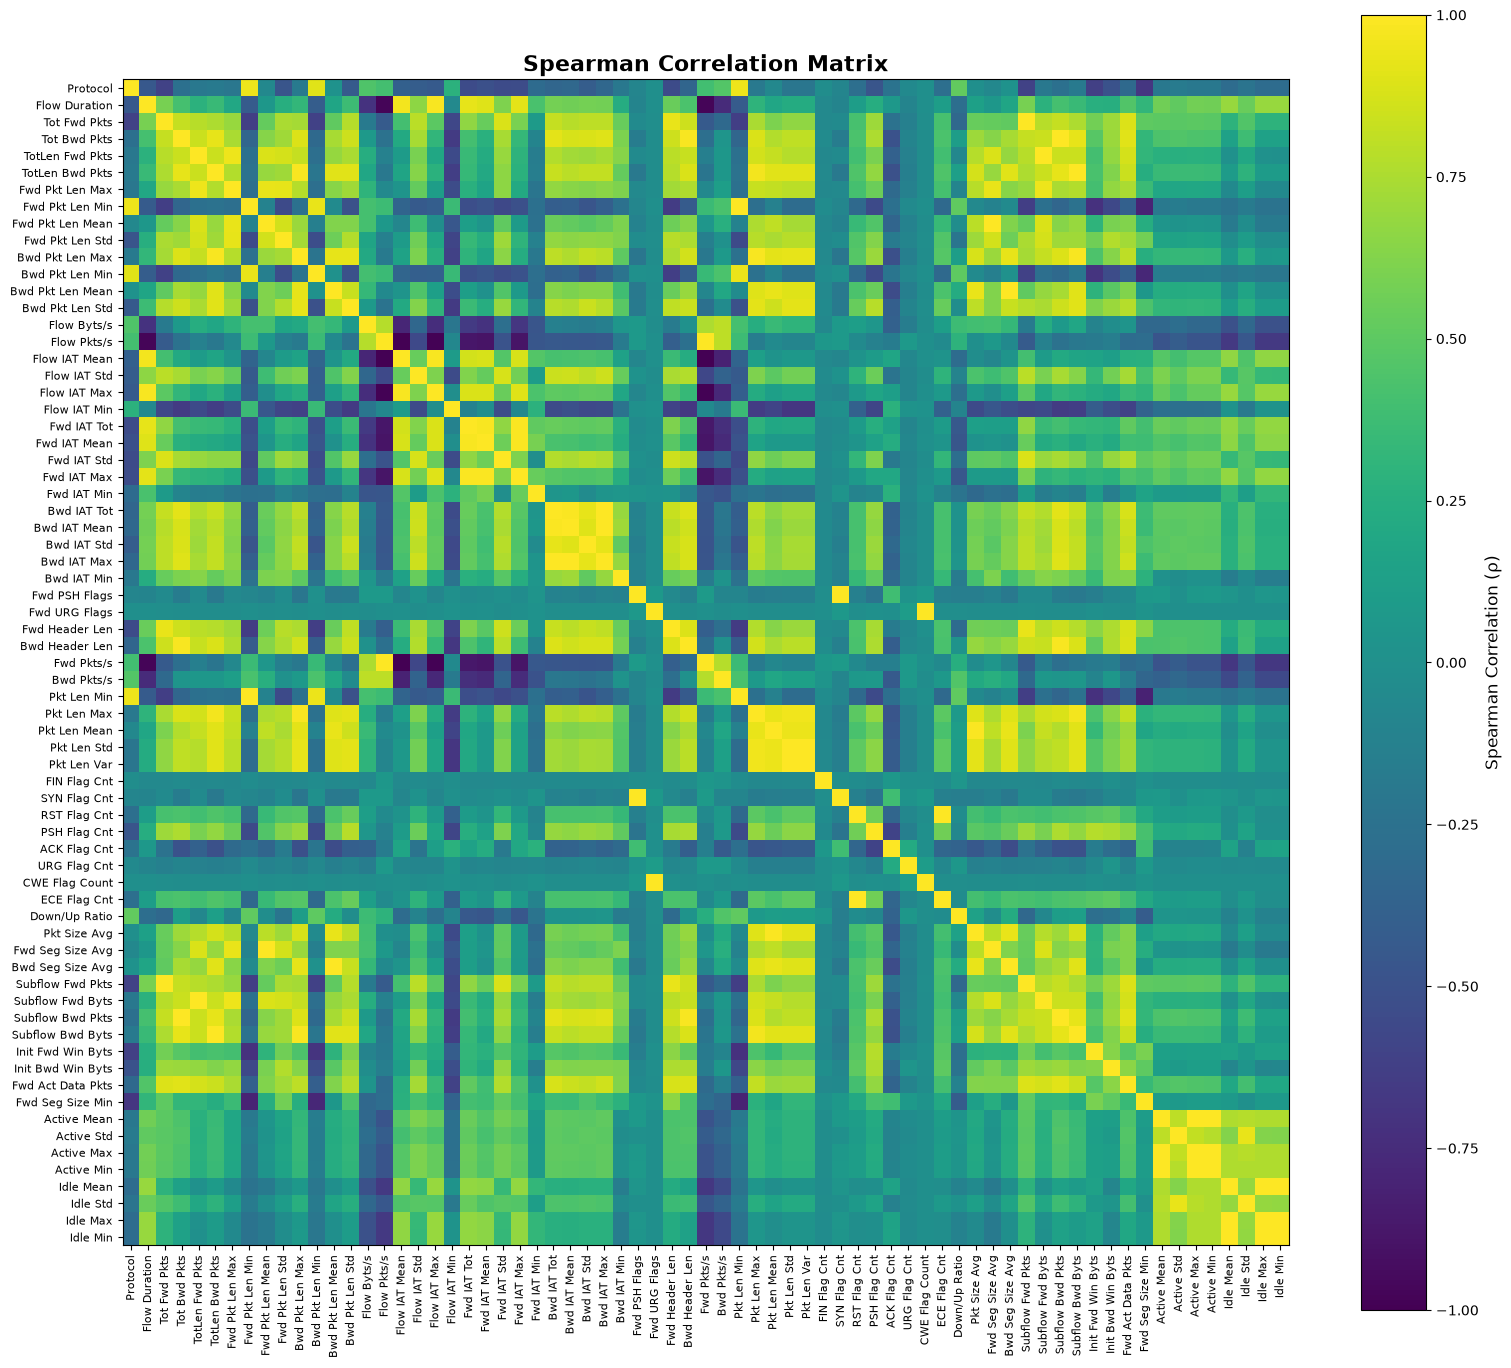

CPU times: user 1.15 s, sys: 201 ms, total: 1.35 s
Wall time: 1.52 s


In [47]:
%%time

correlation_columns = correlation_data.columns
full_correlation_heatmap(correlation_data, "Spearman Correlation Matrix", correlation_columns)

In [48]:
correlation_data

,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,Fwd Pkt Len Std,...,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
Protocol,1.000000,-0.452355,-0.605878,-0.260316,-0.196415,-0.175389,-0.206877,0.946544,-0.066250,-0.472762,...,-0.320180,-0.682689,-0.198338,-0.166310,-0.198402,-0.198380,-0.291275,-0.234038,-0.291045,-0.290806
Flow Duration,-0.452355,1.000000,0.591438,0.412045,0.288332,0.355319,0.199539,-0.424114,0.054965,0.253243,...,0.455234,0.316229,0.570020,0.508116,0.572153,0.567740,0.692846,0.542838,0.693125,0.691560
Tot Fwd Pkts,-0.605878,0.591438,1.000000,0.822523,0.781999,0.753766,0.694910,-0.627278,0.528137,0.744551,...,0.893142,0.503729,0.494588,0.488223,0.499568,0.489365,0.293698,0.459215,0.294710,0.291212
Tot Bwd Pkts,-0.260316,0.412045,0.822523,1.000000,0.841368,0.925575,0.745794,-0.336946,0.639721,0.714528,...,0.907326,0.323653,0.437743,0.456581,0.443151,0.432153,0.140706,0.382283,0.141221,0.140895
TotLen Fwd Pkts,-0.196415,0.288332,0.781999,0.841368,1.000000,0.839765,0.947828,-0.259747,0.887366,0.867325,...,0.873152,0.312888,0.266640,0.263877,0.269319,0.260704,0.008609,0.199566,0.009471,0.007562
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Active Min,-0.198380,0.567740,0.489365,0.432153,0.260704,0.353080,0.182530,-0.187804,0.038533,0.162787,...,0.438233,0.105103,0.997863,0.778355,0.995209,1.000000,0.763364,0.758816,0.765018,0.760991
Idle Mean,-0.291275,0.692846,0.293698,0.140706,0.008609,0.096423,-0.053143,-0.236765,-0.175247,-0.021913,...,0.188880,0.081996,0.763199,0.629063,0.761779,0.763364,1.000000,0.681705,0.999492,0.999280
Idle Std,-0.234038,0.542838,0.459215,0.382283,0.199566,0.291976,0.123215,-0.166620,-0.023009,0.102774,...,0.401731,0.004807,0.774211,0.933238,0.788419,0.758816,0.681705,1.000000,0.687094,0.672475
Idle Max,-0.291045,0.693125,0.294710,0.141221,0.009471,0.096876,-0.052918,-0.236352,-0.174763,-0.022073,...,0.189344,0.082054,0.765172,0.632643,0.763882,0.765018,0.999492,0.687094,1.000000,0.998226


Create a numpy array that keeps only the highly correlated features of the upper triangle
Everything else is set to `nan`

In [49]:
%%time

threshold = 0.95

numpy_matrix = correlation_data.to_numpy().copy()
numpy_matrix[np.abs(numpy_matrix) < threshold] = np.nan # Keep only strong correlations
numpy_matrix[np.tril_indices_from(numpy_matrix, k=-1)] = np.nan

CPU times: user 938 μs, sys: 710 μs, total: 1.65 ms
Wall time: 1.17 ms


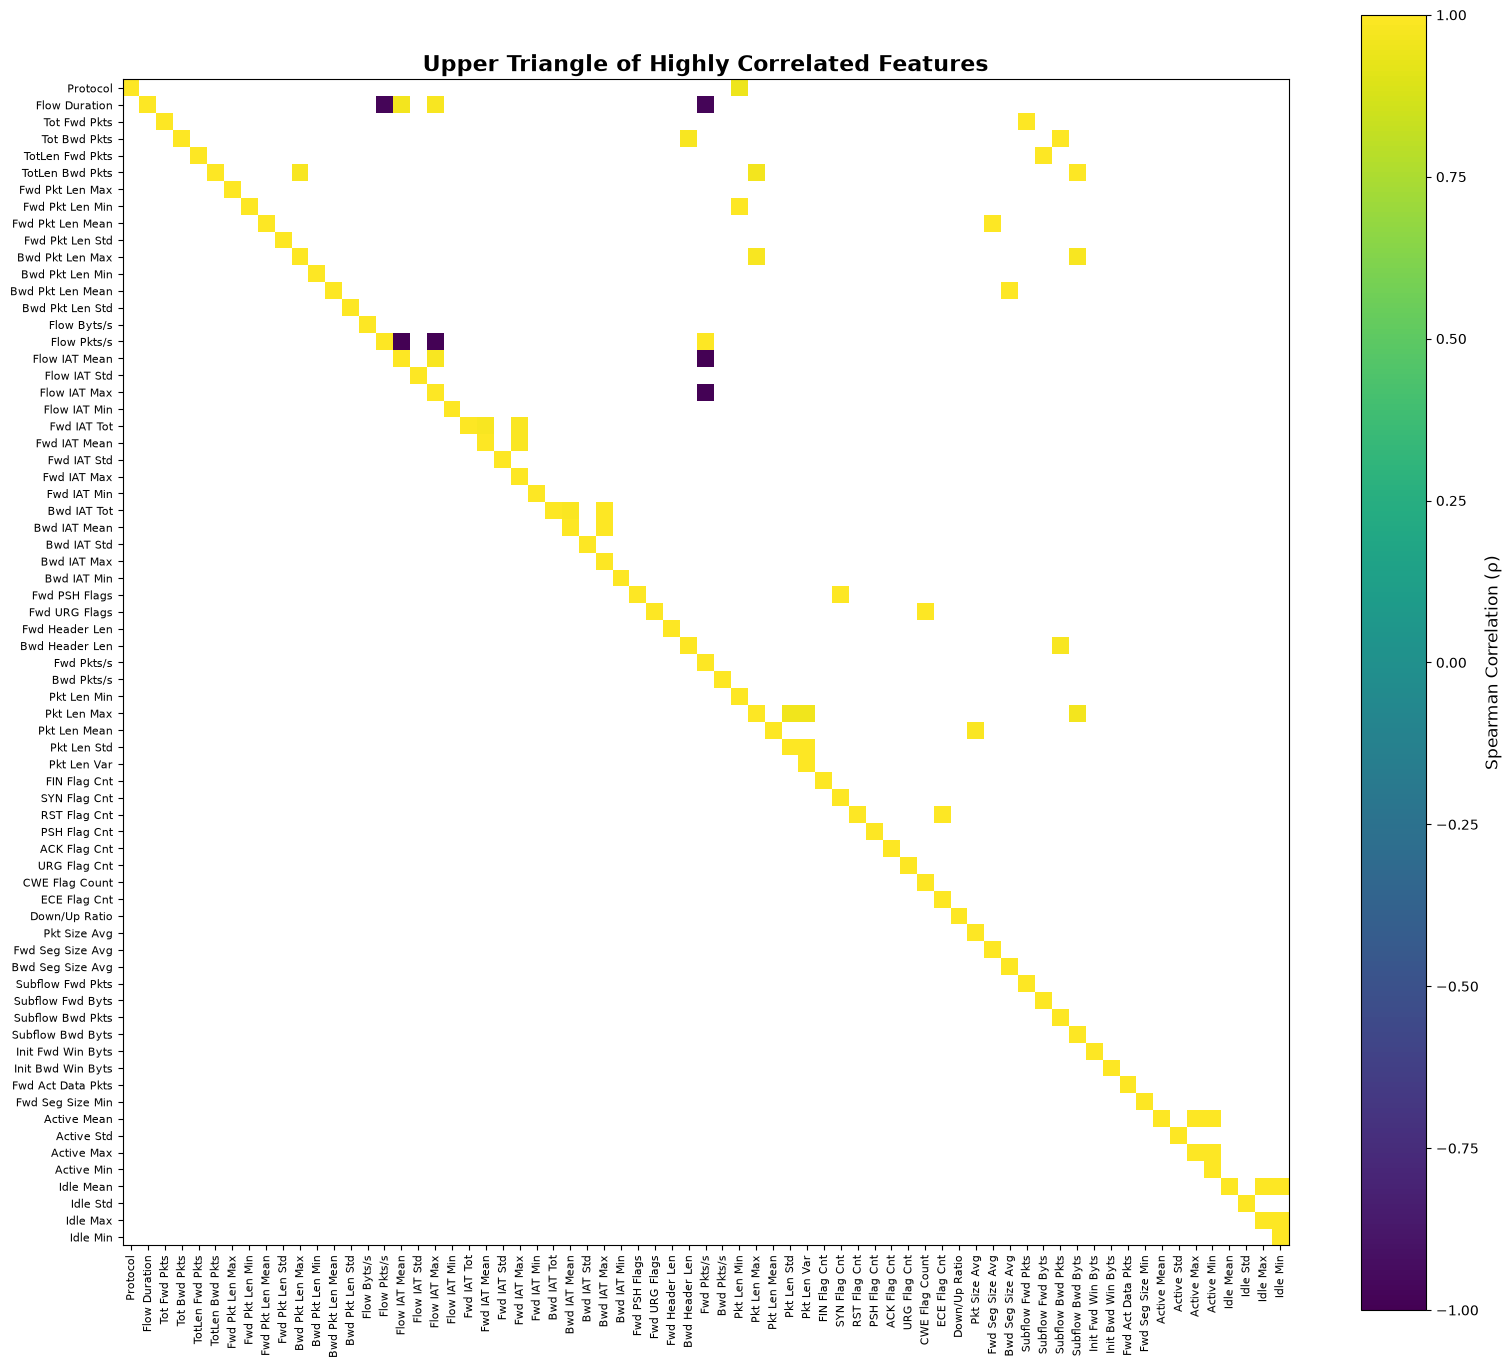

CPU times: user 1.13 s, sys: 48.4 ms, total: 1.18 s
Wall time: 1.19 s


In [50]:
%%time

full_correlation_heatmap(numpy_matrix, "Upper Triangle of Highly Correlated Features", correlation_columns)

Print correlated features

In [51]:
def correlatedColumns(correlation_data):
    """Print correlated columns and their correlation coefficients"""
    rows, cols = np.where(np.triu(correlation_data.to_numpy() > threshold, k=1))

    for r, c in zip(rows, cols):
        row_name = correlation_data.index[r]
        column_name = correlation_data.columns[c]
        print(f"{row_name} <-> {column_name} ({correlation_data[row_name][column_name]})")

In [52]:
%%time

correlatedColumns(correlation_data)

Protocol <-> Pkt Len Min (0.950353253755626)
Flow Duration <-> Flow IAT Mean (0.9627365634786079)
Flow Duration <-> Flow IAT Max (0.9815537119134081)
Tot Fwd Pkts <-> Subflow Fwd Pkts (1.0)
Tot Bwd Pkts <-> Bwd Header Len (0.9794032242813254)
Tot Bwd Pkts <-> Subflow Bwd Pkts (1.0)
TotLen Fwd Pkts <-> Subflow Fwd Byts (1.0)
TotLen Bwd Pkts <-> Bwd Pkt Len Max (0.9842394993347334)
TotLen Bwd Pkts <-> Pkt Len Max (0.9655985932785922)
TotLen Bwd Pkts <-> Subflow Bwd Byts (0.9999999999999999)
Fwd Pkt Len Min <-> Pkt Len Min (0.9959290214053342)
Fwd Pkt Len Mean <-> Fwd Seg Size Avg (0.9999986562672818)
Bwd Pkt Len Max <-> Pkt Len Max (0.9820856424028162)
Bwd Pkt Len Max <-> Subflow Bwd Byts (0.9842394993347389)
Bwd Pkt Len Mean <-> Bwd Seg Size Avg (0.9999999187865695)
Flow Pkts/s <-> Fwd Pkts/s (0.9972741574843702)
Flow IAT Mean <-> Flow IAT Max (0.9791126638672096)
Fwd IAT Tot <-> Fwd IAT Mean (0.9779433354986763)
Fwd IAT Tot <-> Fwd IAT Max (0.9886479816538665)
Fwd IAT Mean <-> Fwd IAT 

In [53]:
correlated_features_to_drop = [
    'Flow IAT Mean',
    'Flow IAT Max',
    'Fwd IAT Tot',
    'Fwd IAT Max',
    'Bwd IAT Tot',
    'Bwd IAT Max',
    'Active Max',
    'Active Min',
    'Idle Max',
    'Idle Min',
    'Subflow Fwd Pkts',
    'Subflow Bwd Pkts',
    'Bwd Header Len',
    'Fwd Pkts/s',
    'Bwd Pkt Len Max',
    'Bwd Pkt Len Mean',
    'Pkt Len Max',
    'Pkt Len Mean',
    'Pkt Len Var',
    'Pkt Size Avg',
    'Bwd Seg Size Avg',
    'Subflow Bwd Byts',
    'Fwd Pkt Len Max',
    'Fwd Seg Size Avg',
    'Subflow Fwd Byts',
    'Fwd Pkt Len Min',
    'ECE Flag Cnt',
    'Fwd PSH Flags',
    'CWE Flag Count'
]

In [54]:
print(f"Features before dropping correlated features: {len(train_df.columns)}")

Features before dropping correlated features: 71


In [55]:
train_df.drop(correlated_features_to_drop, axis=1, inplace=True)

In [56]:
print(f"Features after dropping correlated features: {len(train_df.columns)}")

Features after dropping correlated features: 42


## Feature Importance

Use XGBoost on a stratified dataset subsample to figure out which features have a highest influence on classification decisions

As a baseline benchmark of feature importance, add 10 columns with random data 

In [59]:
%%time

rng = np.random.default_rng(42)

for i in range(10):
    train_df[f"random_probe_{i}"] = rng.random(len(train_df))

In [60]:
labels = train_df['Label']

In [61]:
features = train_df.drop(['Label', 'Label_Short'], axis=1)

In [62]:
labels

8508731                     Benign
6518690                     Benign
2327515     DDoS attacks-LOIC-HTTP
10413527                    Benign
10506275                    Benign
                     ...          
4507796                     Benign
10100684                    Benign
7639574                     Benign
2079101                     Benign
5778253                     Benign
Name: Label, Length: 8655233, dtype: str

In [63]:
features.head()

,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Mean,Fwd Pkt Len Std,Bwd Pkt Len Min,Bwd Pkt Len Std,...,random_probe_0,random_probe_1,random_probe_2,random_probe_3,random_probe_4,random_probe_5,random_probe_6,random_probe_7,random_probe_8,random_probe_9
8508731,6,1002405,2,0,0.0,0.0,0.000000,0.000000,0.0,0.000000,...,0.773956,0.651028,0.686693,0.054424,0.786257,0.014026,0.079339,0.363258,0.313398,0.557086
6518690,17,13154,1,1,41.0,169.0,41.000000,0.000000,169.0,0.000000,...,0.438878,0.751613,0.196031,0.761298,0.755240,0.672353,0.860987,0.466174,0.531792,0.870259
2327515,6,1413645,3,4,20.0,964.0,6.666667,11.547005,0.0,482.000000,...,0.858598,0.486473,0.410270,0.704947,0.943593,0.545152,0.138723,0.736217,0.088897,0.386723
10413527,6,19025,5,2,935.0,339.0,187.000000,418.144712,0.0,239.709199,...,0.697368,0.680762,0.966521,0.530866,0.830208,0.348179,0.554631,0.862922,0.078212,0.102817
10506275,6,3095708,11,12,2017.0,4427.0,183.363636,315.175276,0.0,539.697804,...,0.094177,0.058089,0.239857,0.239801,0.267357,0.160622,0.899790,0.654105,0.112604,0.443678


In [64]:
%%time

le = LabelEncoder()
encoded_labels = le.fit_transform(labels)

CPU times: user 1.17 s, sys: 995 ms, total: 2.17 s
Wall time: 2.19 s


In [65]:
encoded_labels

array([0, 0, 6, ..., 0, 0, 0], shape=(8655233,))

In [66]:
train_df['Encoded_Label'] = encoded_labels

In [67]:
params = {
    'device': 'cuda',
    'objective': 'multi:softprob',
    'eval_metric': 'mlogloss',

    'n_estimators': 300,
    'max_depth': 4,

    'learning_rate': 0.05,

    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'colsample_bylevel': 0.8,

    'min_child_weight': 5,
    'reg_alpha': 0.1,
    'reg_lambda': 1.5,

    'tree_method': 'hist',
}

Retrain XGBoost classifier with 5 different seeds for train/test data split and XGBoost randomness

Data collected:
1. For each feature, collect feature importance metrics:
    * Gain
    * Weight
    * Cover
    * Relative Importance
    * Rank
2. For each metric, collect values and compute:
    * Standard Deviation
    * Mean
    * Coefficient of Variance

Results are written to JSON file

In [68]:
def serializeNumpy(obj):
    """Serialize Numpy value of any type to JSON"""
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, np.generic):
        return obj.item()
    raise TypeError(f"Object of type {type(obj).__name__} is not JSON serializable")

In [69]:
%%time

cv_counter = 1
cv_iterations = 5
IMPORTANCE_TYPES = ["gain", "weight", "cover"]
feature_importance_stats = {}

for columns in features.columns:
    feature_importance_stats[columns] = {
        "gain": {
            "data": [],
            "std": 0,
            "mean": 0,
            "cv": 0
        },
        "weight": {
            "data": [],
            "std": 0,
            "mean": 0,
            "cv": 0
        },
        "cover": {
            "data": [],
            "std": 0,
            "mean": 0,
            "cv": 0
        },
        "importance": {
            "data": [],
            "std": 0,
            "mean": 0,
            "cv": 0
        },
        "rank": {
            "data": [],
            "std": 0,
            "mean": 0,
            "cv": 0
        }
    }

X_train = train_df.drop(columns=["Label", "Label_Short", "Encoded_Label"])
y_train = train_df["Encoded_Label"]

params['random_state'] = 42
params['num_class'] = len(y_train.unique())
model = xgb.XGBClassifier(**params)

start = time.time()
print("Creating stratified K-Fold")

cv = StratifiedKFold(
    n_splits=cv_iterations,
    shuffle=True,
    random_state=42
)

end = time.time()
print(f"Creating stratified K-Fold finished in {end - start} seconds")

for train_idx, val_idx in cv.split(X_train, y_train):
    start = time.time()

    print(f"Starting CV {cv_counter}/{cv_iterations}...")

    model.fit(
        X_train.iloc[train_idx],
        y_train.iloc[train_idx]
    )

    importances_dict = {name: importance for name, importance in zip(model.feature_names_in_, model.feature_importances_)}

    importances_dict_sorted = {k: v for k, v in sorted(importances_dict.items(), key=lambda item: item[1])}

    rank = len(features.columns)

    for key, value in importances_dict_sorted.items():
        feature_importance_stats[key]["importance"]["data"].append(value)
        feature_importance_stats[key]["rank"]["data"].append(rank)
        rank -= 1

    booster = model.get_booster()
    for itype in IMPORTANCE_TYPES:
        for key, value in booster.get_score(importance_type=itype).items():
            feature_importance_stats[key][itype]["data"].append(value)

    end = time.time()
    print(f"CV iteration {cv_counter}/{cv_iterations} finished in {end - start} seconds")
    cv_counter += 1

for column in feature_importance_stats:
    for key in feature_importance_stats[column]:
        data = feature_importance_stats[column][key]["data"]
        std = np.std(data)
        feature_importance_stats[column][key]["std"] = std
        mean = np.mean(data)
        feature_importance_stats[column][key]["mean"] = mean
        cv = (std / mean) * 100
        feature_importance_stats[column][key]["cv"] = cv

# Write statistics to a JSON file
with open("data.json", "w") as f:
    f.write(json.dumps(feature_importance_stats, default=serializeNumpy, indent=4))

Creating stratified K-Fold
Creating stratified K-Fold finished in 0.0004024505615234375 seconds
Starting CV 1/5...
CV iteration 1/5 finished in 466.18112444877625 seconds
Starting CV 2/5...
CV iteration 2/5 finished in 440.45278429985046 seconds
Starting CV 3/5...
CV iteration 3/5 finished in 423.5020127296448 seconds
Starting CV 4/5...
CV iteration 4/5 finished in 420.610337972641 seconds
Starting CV 5/5...
CV iteration 5/5 finished in 415.7172305583954 seconds
CPU times: user 40min 4s, sys: 25.6 s, total: 40min 30s
Wall time: 36min 9s


# Plotting Feature Statistics

For every statistical feature, plot the following:
1. Log plot:
    * Coefficient of Variance (CV)
    * Mean
2. Scatterplot (CV + Mean)

In [70]:
gain_mean, gain_cv, weight_mean, weight_cv, cover_mean, cover_cv, importance_mean, importance_cv, rank_mean, rank_cv = [{} for x in range(10)]

In [71]:
for column in feature_importance_stats.keys():
    for metric in feature_importance_stats[column].keys():
        mean = feature_importance_stats[column][metric]["mean"]
        cv = feature_importance_stats[column][metric]["cv"]
        if metric == "gain":
            gain_mean[column] = mean
            gain_cv[column] = cv
        elif metric == "weight":
            weight_mean[column] = mean
            weight_cv[column] = cv
        elif metric == "cover":
            cover_mean[column] = mean
            cover_cv[column] = cv
        elif metric == "importance":
            importance_mean[column] = mean
            importance_cv[column] = cv
        elif metric == "rank":
            rank_mean[column] = mean
            rank_cv[column] = cv

In [72]:
gain_mean_sorted = {k: v for k, v in sorted(gain_mean.items(), key=lambda item: item[1])}
gain_cv_sorted = {k: v for k, v in sorted(gain_cv.items(), key=lambda item: item[1])}
weight_mean_sorted = {k: v for k, v in sorted(weight_mean.items(), key=lambda item: item[1])}
weight_cv_sorted = {k: v for k, v in sorted(weight_cv.items(), key=lambda item: item[1])}
cover_mean_sorted = {k: v for k, v in sorted(cover_mean.items(), key=lambda item: item[1])}
cover_cv_sorted = {k: v for k, v in sorted(cover_cv.items(), key=lambda item: item[1])}
importance_mean_sorted = {k: v for k, v in sorted(importance_mean.items(), key=lambda item: item[1])}
importance_cv_sorted = {k: v for k, v in sorted(importance_cv.items(), key=lambda item: item[1])}
rank_mean_sorted = {k: v for k, v in sorted(rank_mean.items(), key=lambda item: item[1])}
rank_cv_sorted = {k: v for k, v in sorted(rank_cv.items(), key=lambda item: item[1])}

In [73]:
def feature_importance(plot_data, title, xlabel, ylabel, threshold):
    """Coefficient of variance for XGBoost-ranked variables"""
    x, y = [[] for z in range(2)]
    length = len(plot_data.items()) - 1
    for key, value in plot_data.items():
        x.append(key)
        y.append(value)
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.grid(True, alpha=0.3)
    ax.set_yscale("log")  # Convert y-axis to logarithmic scale
    ax.plot(x, y, "o-", color="green")
    if threshold > 0:
        ax.plot([0, length], [threshold, threshold], "k--")
    ax.set_xlabel(f"{xlabel}")
    ax.set_ylabel(f"{ylabel}")
    fig.tight_layout()
    plt.xticks(rotation=90)
    plt.title(f"{title}", fontsize = 16, fontweight="bold")
    plt.show()
    fig.savefig(f"images/{title}.png", bbox_inches="tight")
    fig.clear()
    plt.close(fig)

## Mean and CV Plots

In [107]:
random_columns = [f"random_probe_{x}" for x in range(10)]

gain_mean_threshold = np.max([gain_mean_sorted[x] for x in random_columns])
gain_cv_threshold = np.max([gain_cv_sorted[x] for x in random_columns])
weight_mean_threshold = np.max([weight_mean_sorted[x] for x in random_columns])
weight_cv_threshold = np.max([weight_cv_sorted[x] for x in random_columns])
cover_mean_threshold = np.max([cover_mean_sorted[x] for x in random_columns])
cover_cv_threshold = np.max([cover_cv_sorted[x] for x in random_columns])
importance_mean_threshold = np.max([importance_mean_sorted[x] for x in random_columns])
importance_cv_threshold = np.max([importance_cv_sorted[x] for x in random_columns])
rank_mean_threshold = np.min([rank_mean_sorted[x] for x in random_columns])
rank_cv_threshold = np.min([rank_cv_sorted[x] for x in random_columns])

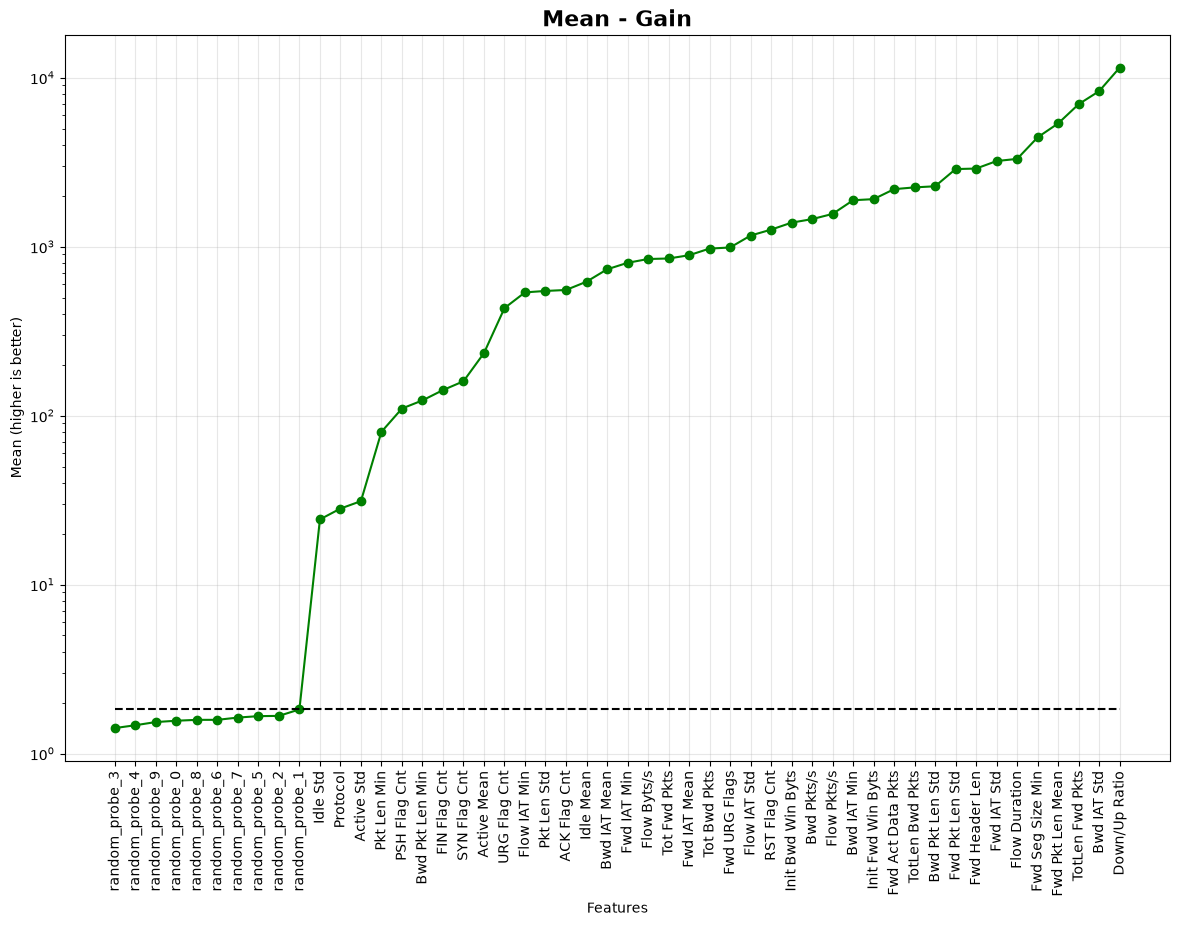

CPU times: user 990 ms, sys: 57.4 ms, total: 1.05 s
Wall time: 1.11 s


In [75]:
%%time

feature_importance(
    gain_mean_sorted,
    "Mean - Gain",
    "Features",
    "Mean (higher is better)",
    gain_mean_threshold
)

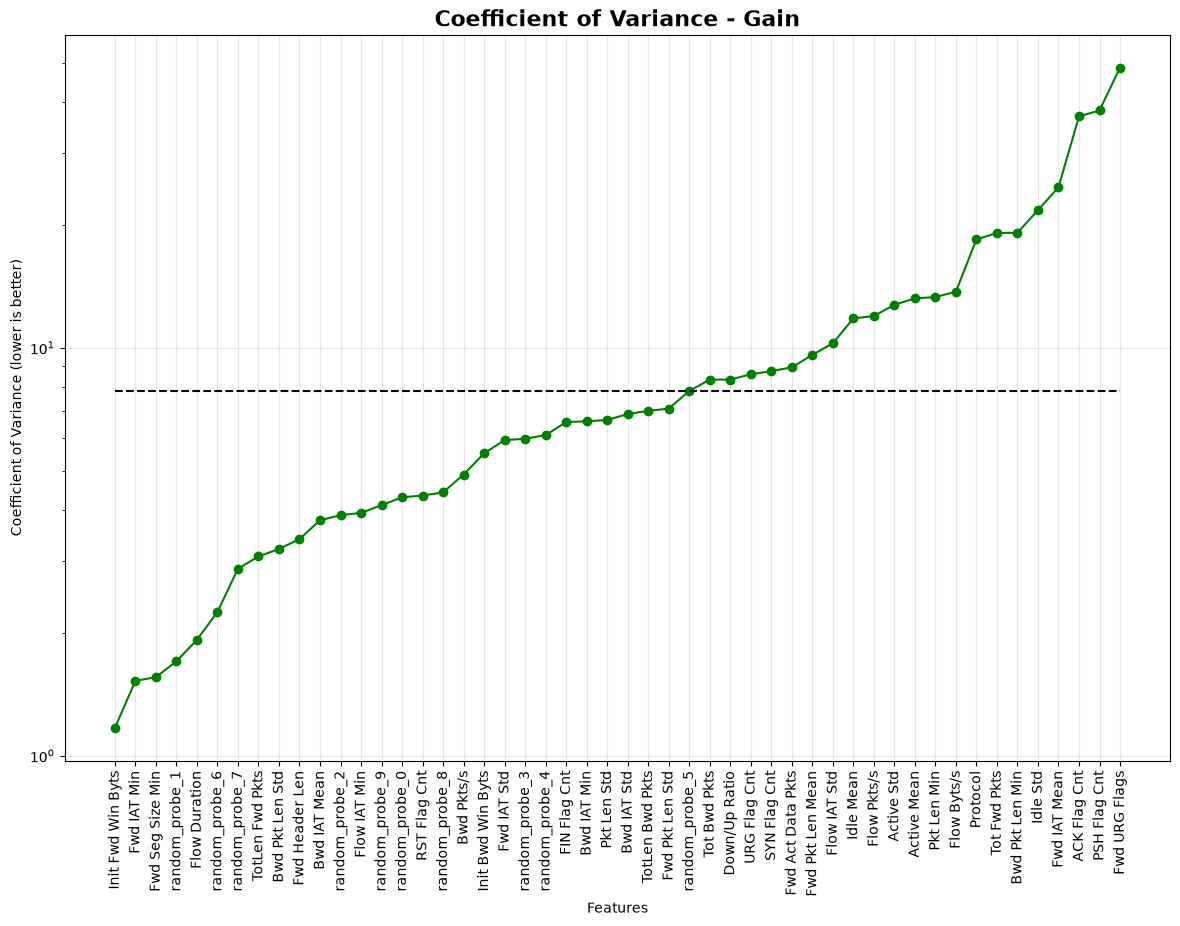

CPU times: user 1 s, sys: 53.6 ms, total: 1.06 s
Wall time: 1.06 s


In [76]:
%%time

feature_importance(
    gain_cv_sorted,
    "Coefficient of Variance - Gain",
    "Features",
    "Coefficient of Variance (lower is better)",
    gain_cv_threshold
)

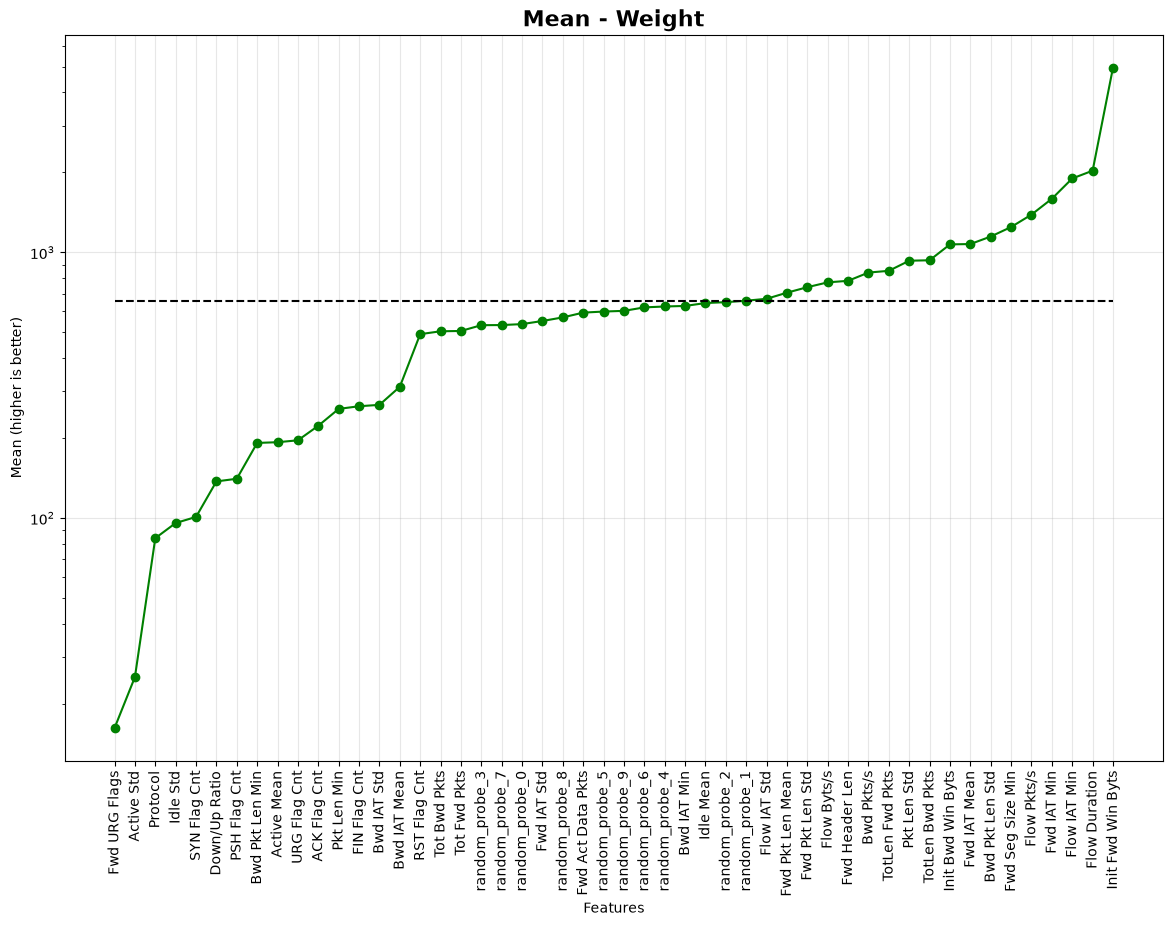

CPU times: user 1.02 s, sys: 50.5 ms, total: 1.07 s
Wall time: 1.07 s


In [77]:
%%time

feature_importance(
    weight_mean_sorted,
    "Mean - Weight",
    "Features",
    "Mean (higher is better)",
    weight_mean_threshold
)

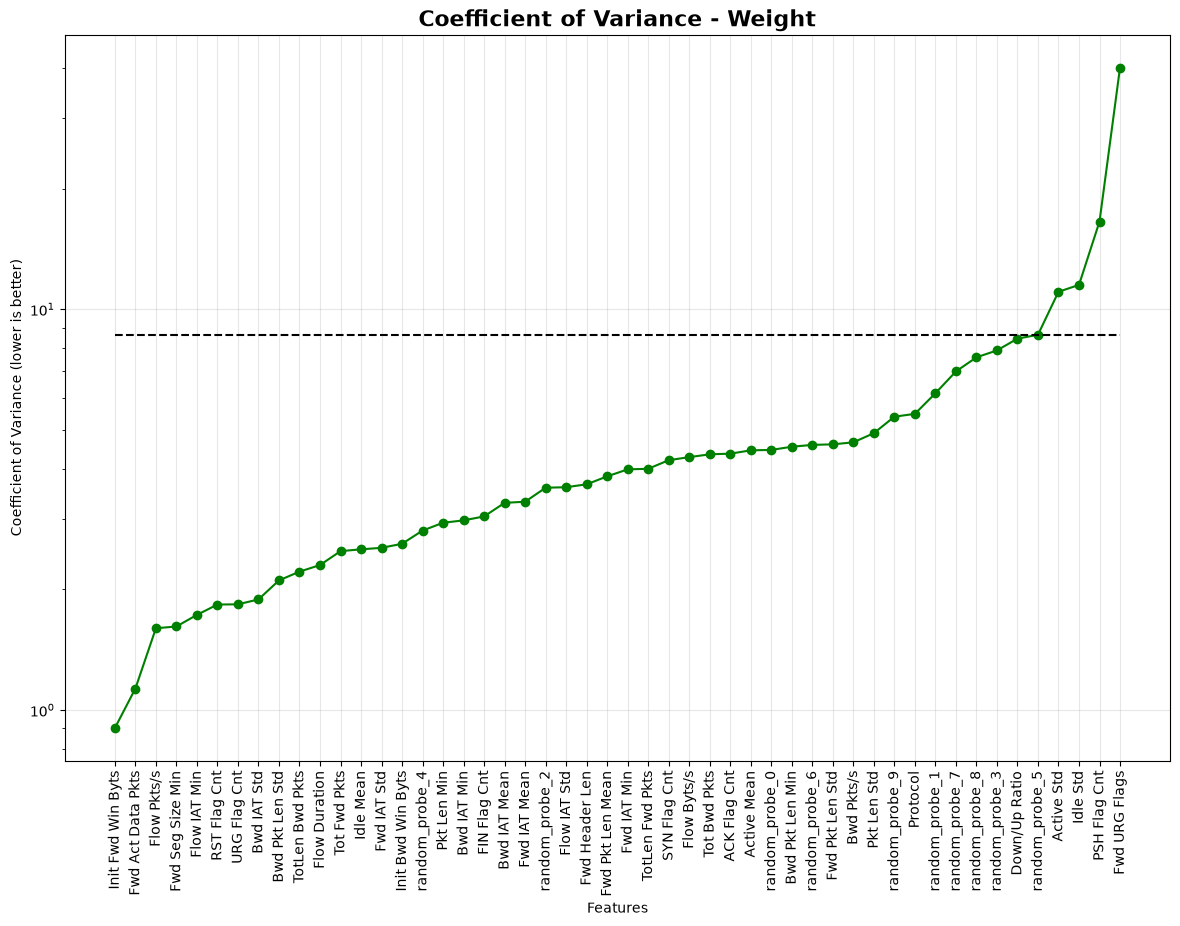

CPU times: user 943 ms, sys: 36.6 ms, total: 979 ms
Wall time: 1.01 s


In [78]:
%%time

feature_importance(
    weight_cv_sorted,
    "Coefficient of Variance - Weight",
    "Features",
    "Coefficient of Variance (lower is better)",
    weight_cv_threshold
)

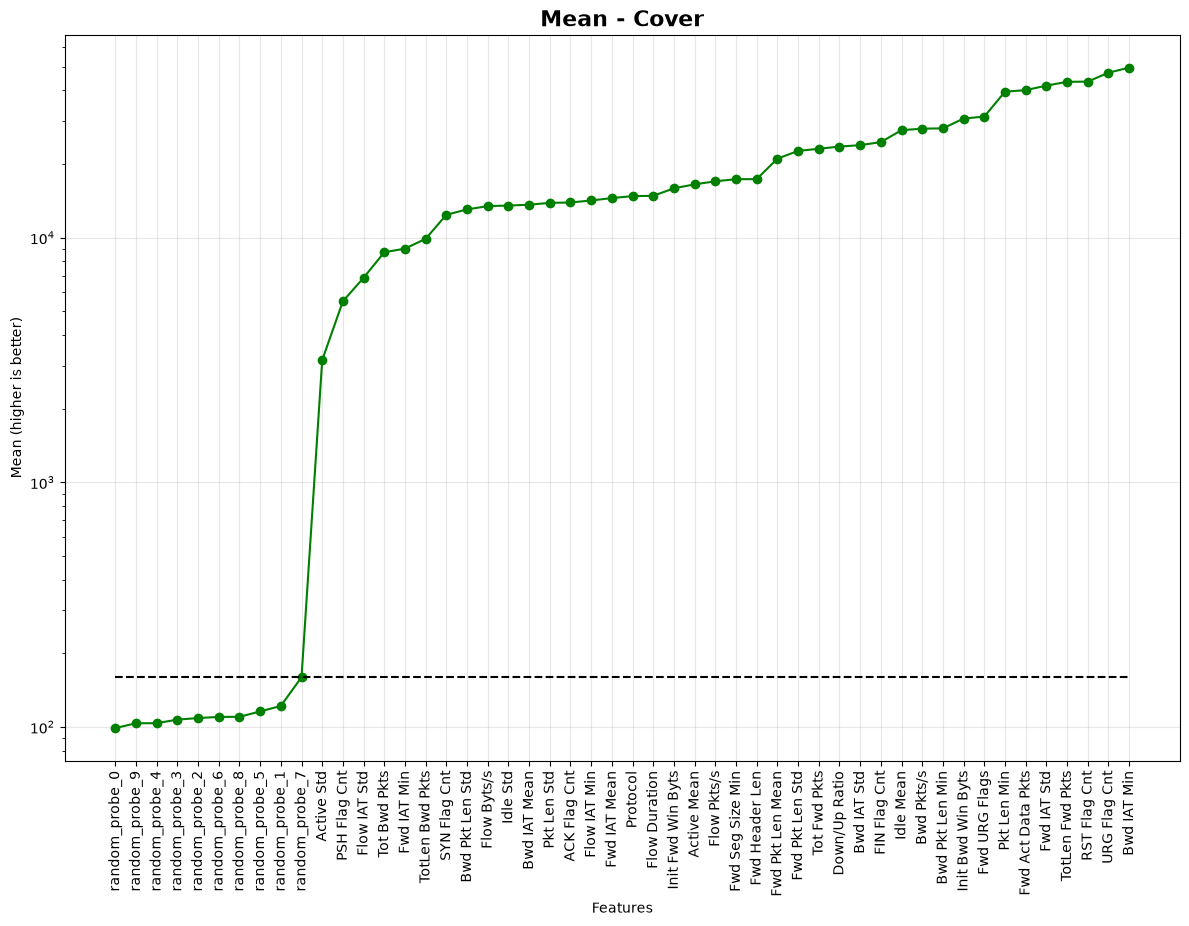

CPU times: user 906 ms, sys: 54.6 ms, total: 960 ms
Wall time: 989 ms


In [79]:
%%time

feature_importance(
    cover_mean_sorted,
    "Mean - Cover",
    "Features",
    "Mean (higher is better)",
    cover_mean_threshold
)

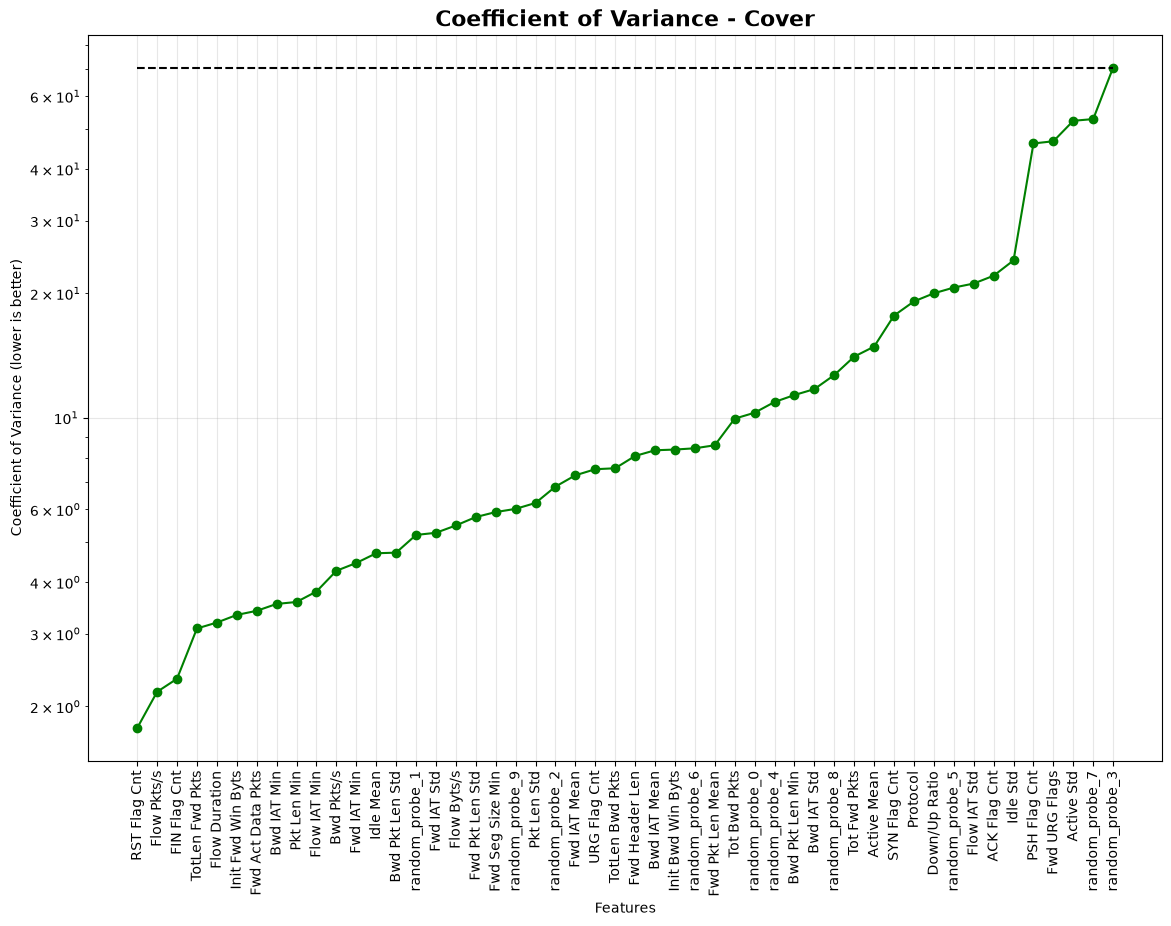

CPU times: user 1.16 s, sys: 44.4 ms, total: 1.2 s
Wall time: 1.24 s


In [80]:
%%time

feature_importance(
    cover_cv_sorted,
    "Coefficient of Variance - Cover",
    "Features",
    "Coefficient of Variance (lower is better)",
    cover_cv_threshold
)

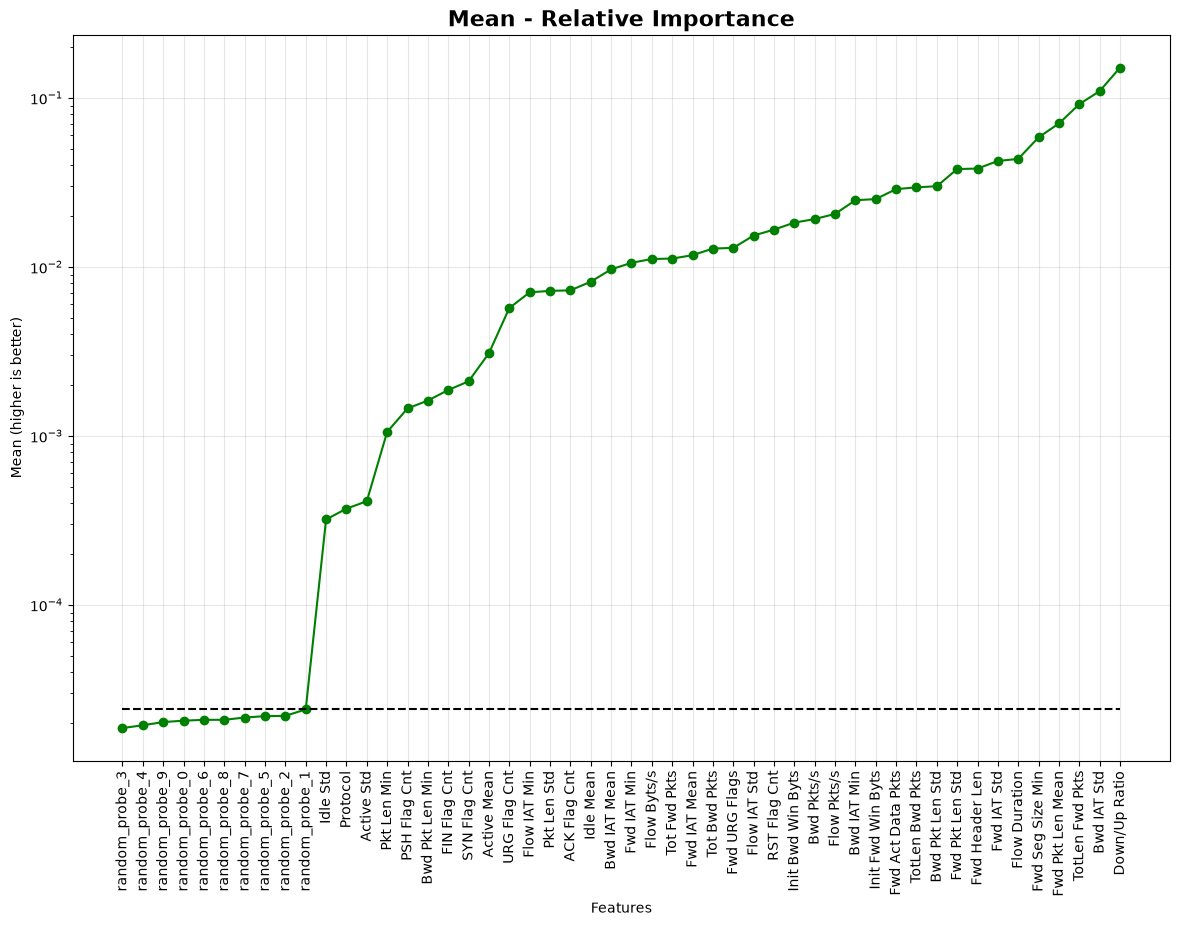

CPU times: user 1.04 s, sys: 312 ms, total: 1.35 s
Wall time: 1.41 s


In [81]:
%%time

feature_importance(
    importance_mean_sorted,
    "Mean - Relative Importance",
    "Features",
    "Mean (higher is better)",
    importance_mean_threshold
)

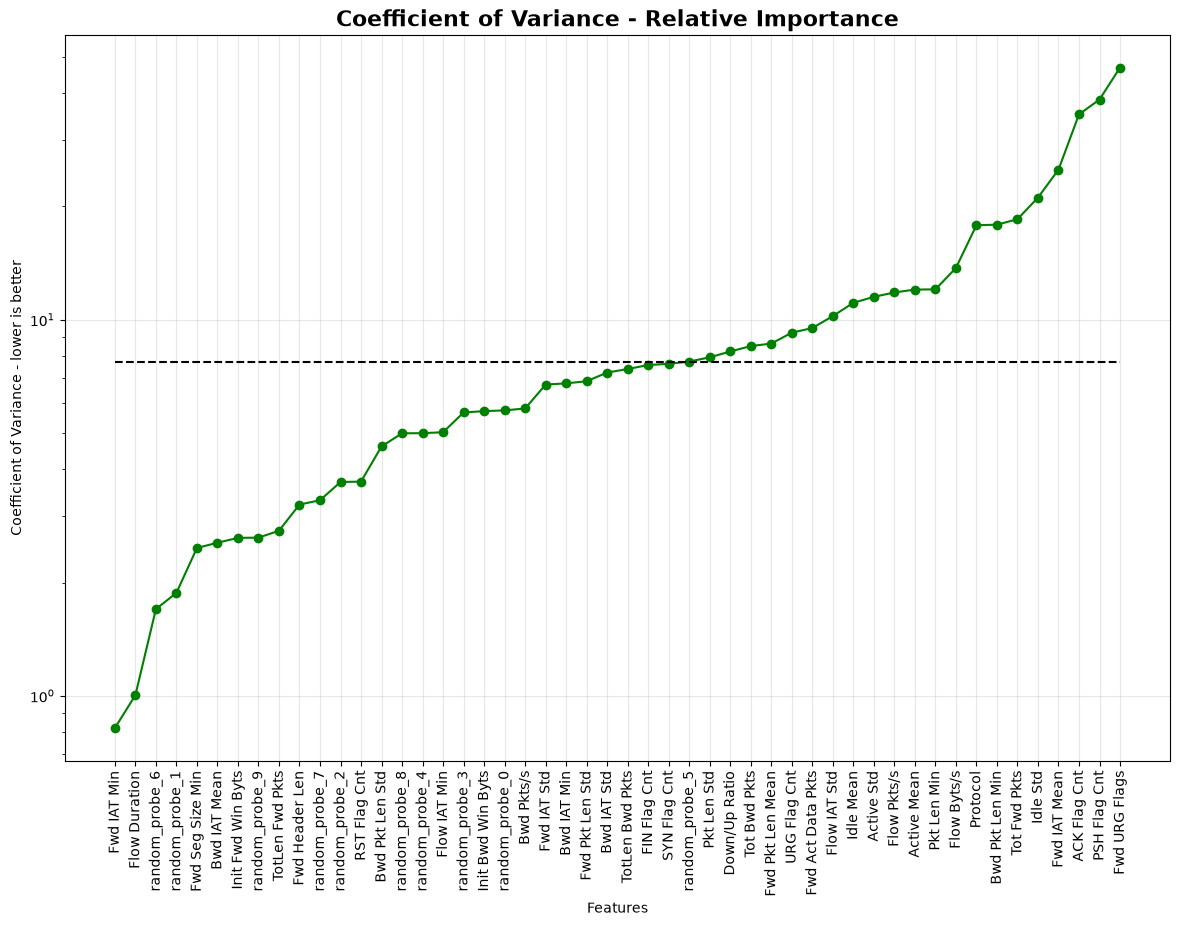

CPU times: user 851 ms, sys: 36.7 ms, total: 888 ms
Wall time: 887 ms


In [82]:
%%time

feature_importance(
    importance_cv_sorted,
    "Coefficient of Variance - Relative Importance",
    "Features",
    "Coefficient of Variance - lower is better",
    importance_cv_threshold
)

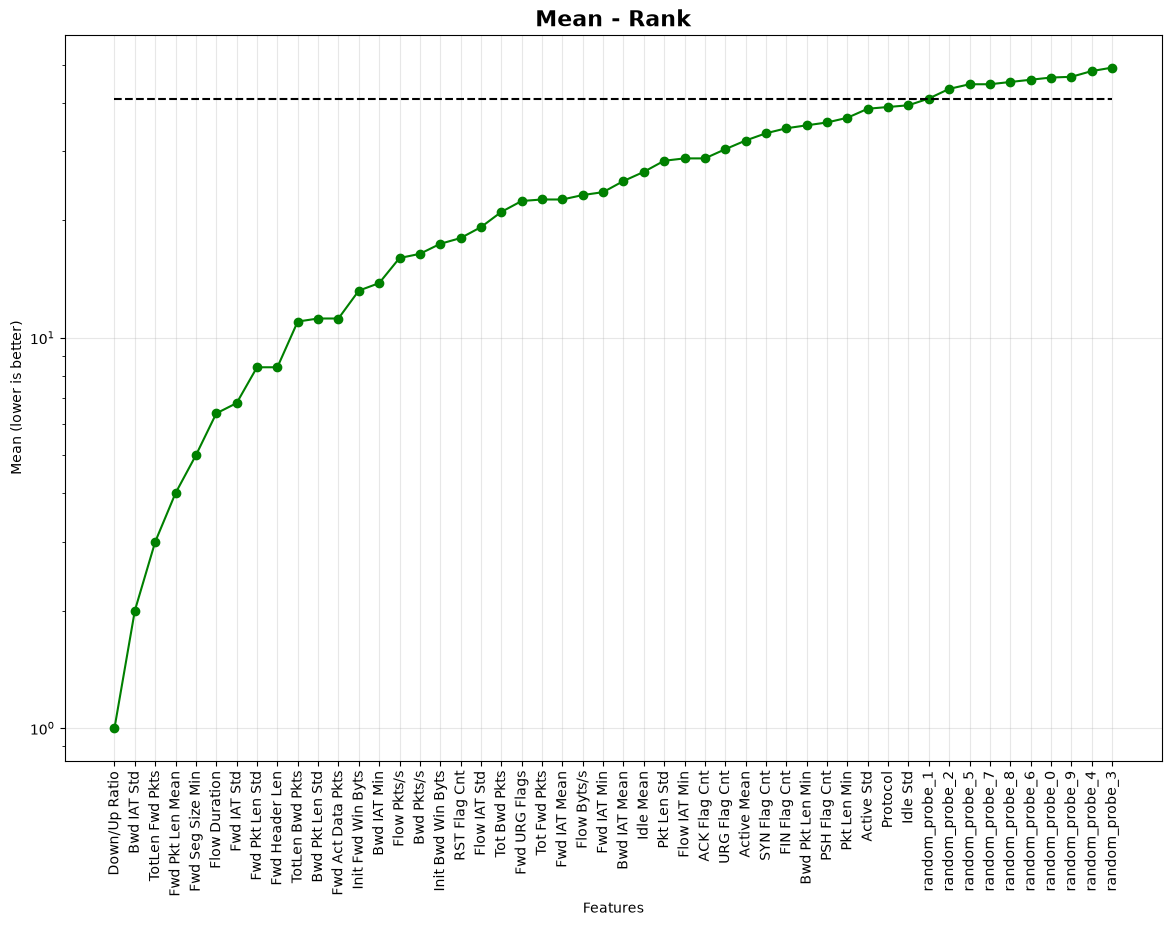

CPU times: user 1.02 s, sys: 36.8 ms, total: 1.06 s
Wall time: 1.06 s


In [83]:
%%time

feature_importance(
    rank_mean_sorted,
    "Mean - Rank",
    "Features",
    "Mean (lower is better)",
    rank_mean_threshold
)

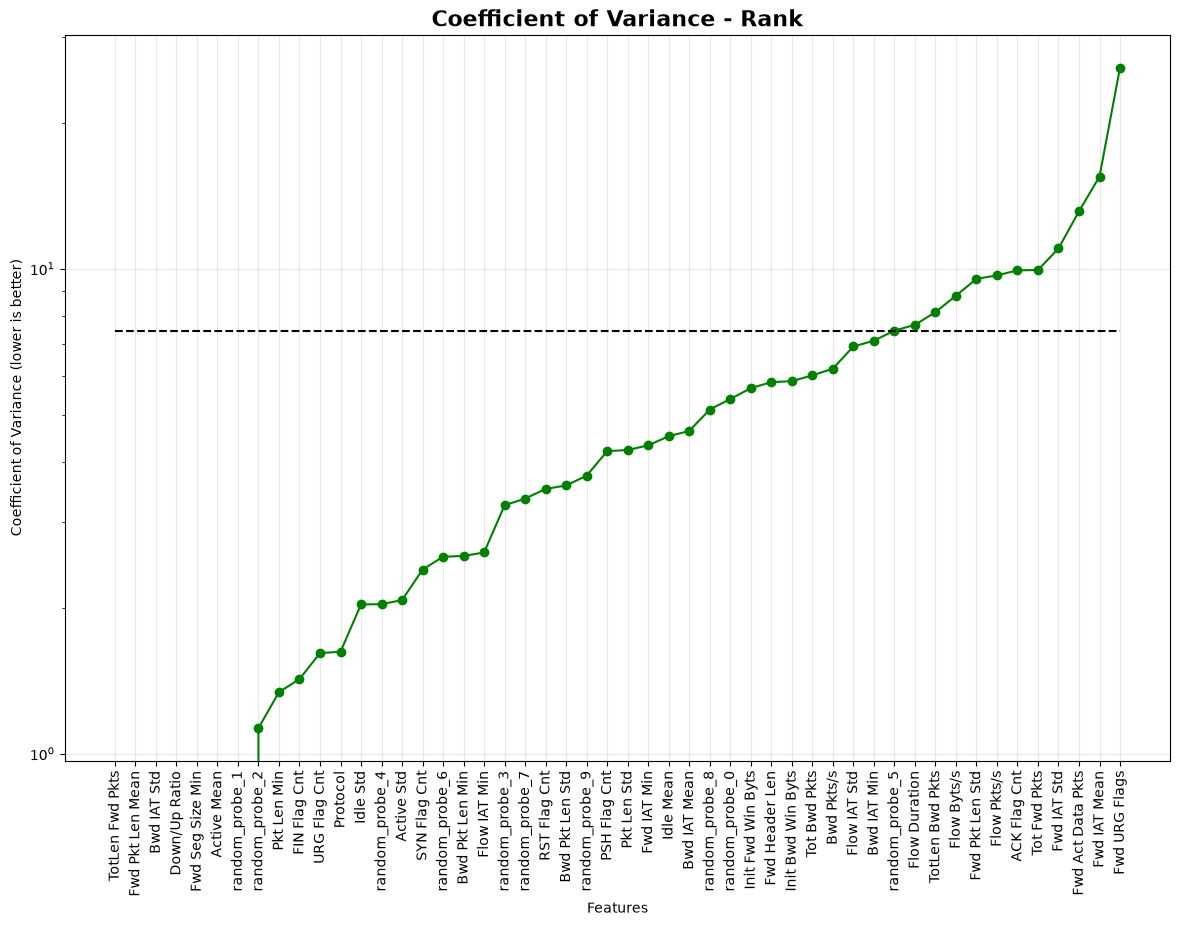

CPU times: user 838 ms, sys: 37.7 ms, total: 875 ms
Wall time: 879 ms


In [108]:
%%time

feature_importance(
    rank_cv_sorted,
    "Coefficient of Variance - Rank",
    "Features",
    "Coefficient of Variance (lower is better)",
    rank_cv_threshold
)

## Scatterplots

In [85]:
gain_scatter, weight_scatter, cover_scatter, importance_scatter, rank_scatter = [{} for x in range(5)]
for key in features.columns:
    gain_scatter[key] = {
        "mean": gain_mean_sorted[key],
        "cv": gain_cv_sorted[key]
    }
    weight_scatter[key] = {
        "mean": weight_mean_sorted[key],
        "cv": weight_cv_sorted[key]
    }
    cover_scatter[key] = {
        "mean": cover_mean_sorted[key],
        "cv": cover_cv_sorted[key]
    }
    importance_scatter[key] = {
        "mean": importance_mean_sorted[key],
        "cv": importance_cv_sorted[key]
    }
    rank_scatter[key] = {
        "mean": rank_mean_sorted[key],
        "cv": rank_cv_sorted[key]
    }

In [86]:
def boolMask(mean_value, cv_value, mean_threshold, cv_threshold):
    """
    Create a boolean mask for mean and coefficient of variation (CV) variables.
    Boolean mask slices a scatter plot into 4 quadrants:
        High mean low CV
        High mean high CV
        Low mean low CV
        low mean high CV
    """
    high_mean_low_cv, high_mean_high_cv, low_mean_low_cv, low_mean_high_cv = [[] for x in range(4)]

    for mean, cv in zip(mean_value, cv_value):
        if (mean > mean_threshold) and (cv < cv_threshold):
            high_mean_low_cv.append(True)
            high_mean_high_cv.append(False)
            low_mean_low_cv.append(False)
            low_mean_high_cv.append(False)
        elif (mean > mean_threshold) and (cv >= cv_threshold):
            high_mean_low_cv.append(False)
            high_mean_high_cv.append(True)
            low_mean_low_cv.append(False)
            low_mean_high_cv.append(False)
        elif (mean <= mean_threshold) and (cv < cv_threshold):
            high_mean_low_cv.append(False)
            high_mean_high_cv.append(False)
            low_mean_low_cv.append(True)
            low_mean_high_cv.append(False)
        elif (mean <= mean_threshold) and (cv >= cv_threshold):
            high_mean_low_cv.append(False)
            high_mean_high_cv.append(False)
            low_mean_low_cv.append(False)
            low_mean_high_cv.append(True)

    return high_mean_low_cv, high_mean_high_cv, low_mean_low_cv, low_mean_high_cv

In [87]:
def scatterPlot(scatter_dict, title, xlabel, ylabel, mean_threshold, cv_threshold):
    """
    Scatter plot between mean and coefficient of variation (CV)
    Scatter plots with 4 quadrants (described in a comment of boolMask function) are computed for 5 variables:
        Gain
        Weight
        Cover
        Relative Importance
        Rank
    """
    mean_values = np.array([scatter_dict[x]["mean"] for x in scatter_dict])
    cv_values = np.array([scatter_dict[x]["cv"] for x in scatter_dict])

    high_mean_low_cv, high_mean_high_cv, low_mean_low_cv, low_mean_high_cv = boolMask(mean_values, cv_values, mean_threshold, cv_threshold)

    fig, ax = plt.subplots(figsize=(12, 8))
    
    ax.scatter(
        mean_values[high_mean_low_cv],
        cv_values[high_mean_low_cv],
        label="High mean / Low CV"
    )

    ax.scatter(
        mean_values[high_mean_high_cv],
        cv_values[high_mean_high_cv],
        label="High mean / High CV"
    )

    ax.scatter(
        mean_values[low_mean_low_cv],
        cv_values[low_mean_low_cv],
        label="Low mean / Low CV"
    )

    ax.scatter(
        mean_values[low_mean_high_cv],
        cv_values[low_mean_high_cv],
        label="Low mean / High CV"
    )

    # Threshold lines
    ax.axvline(
        mean_threshold,
        color="black",
        linestyle="--",
        alpha=0.3
    )

    ax.axhline(
        cv_threshold,
        color="black",
        linestyle="--",
        alpha=0.3
    )

    # Important quadrant
    if title == "Mean and Stability - Rank":
        x0, x1 = 0, mean_threshold
    else:
        x0, x1 = mean_threshold, ax.get_xlim()[1]

    y0, y1 = 0, cv_threshold

    ax.add_patch(
        Rectangle(
            (x0, y0),
            x1 - x0,
            y1 - y0,
            alpha=0.15
        )
    )
    
    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_title(
        f"{title}",
        fontsize = 16,
        fontweight="bold"
    )
    ax.set_xlabel(f"{xlabel}")
    ax.set_ylabel(f"{ylabel}")

    ax.legend()

    ax.grid(
        True,
        alpha=0.3
    )

    fig.savefig(f"images/{title}.png", bbox_inches="tight")
    
    plt.tight_layout()
    plt.show()

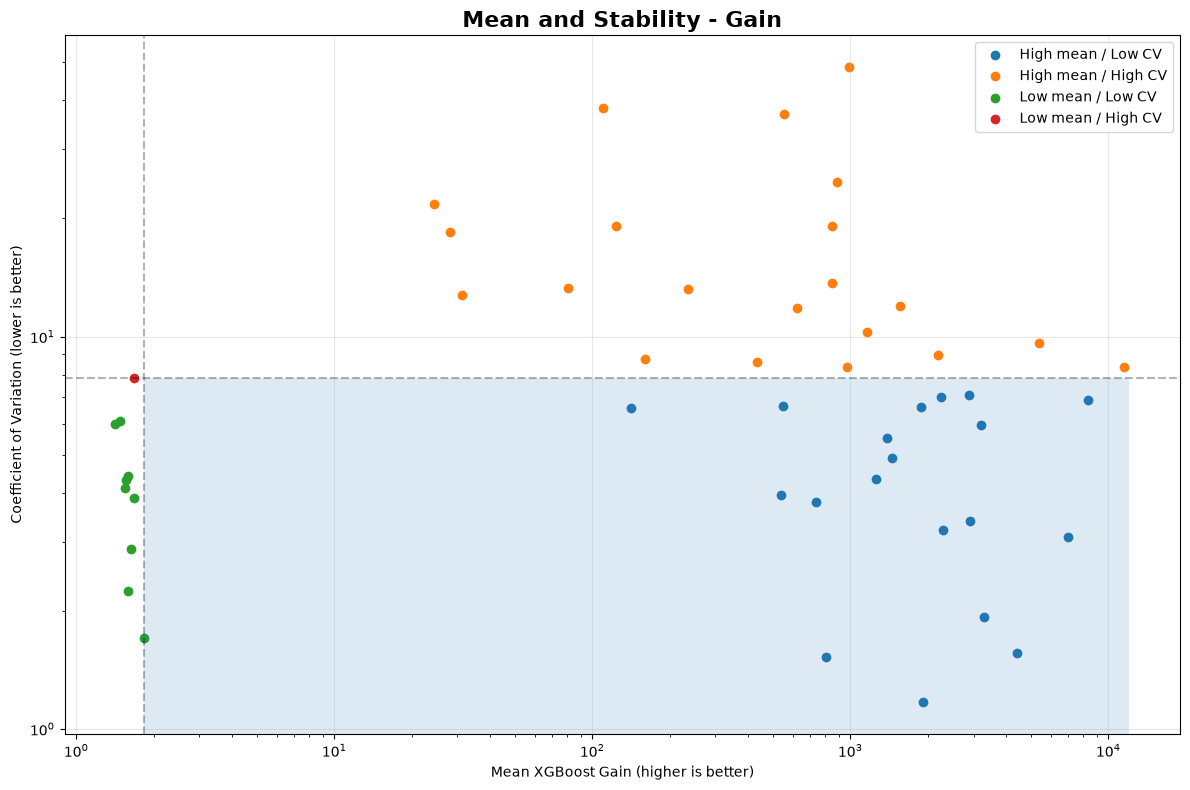

CPU times: user 647 ms, sys: 14 ms, total: 661 ms
Wall time: 663 ms


In [88]:
%%time

scatterPlot(
    gain_scatter,
    "Mean and Stability - Gain",
    "Mean XGBoost Gain (higher is better)",
    "Coefficient of Variation (lower is better)",
    gain_mean_threshold,
    gain_cv_threshold
)

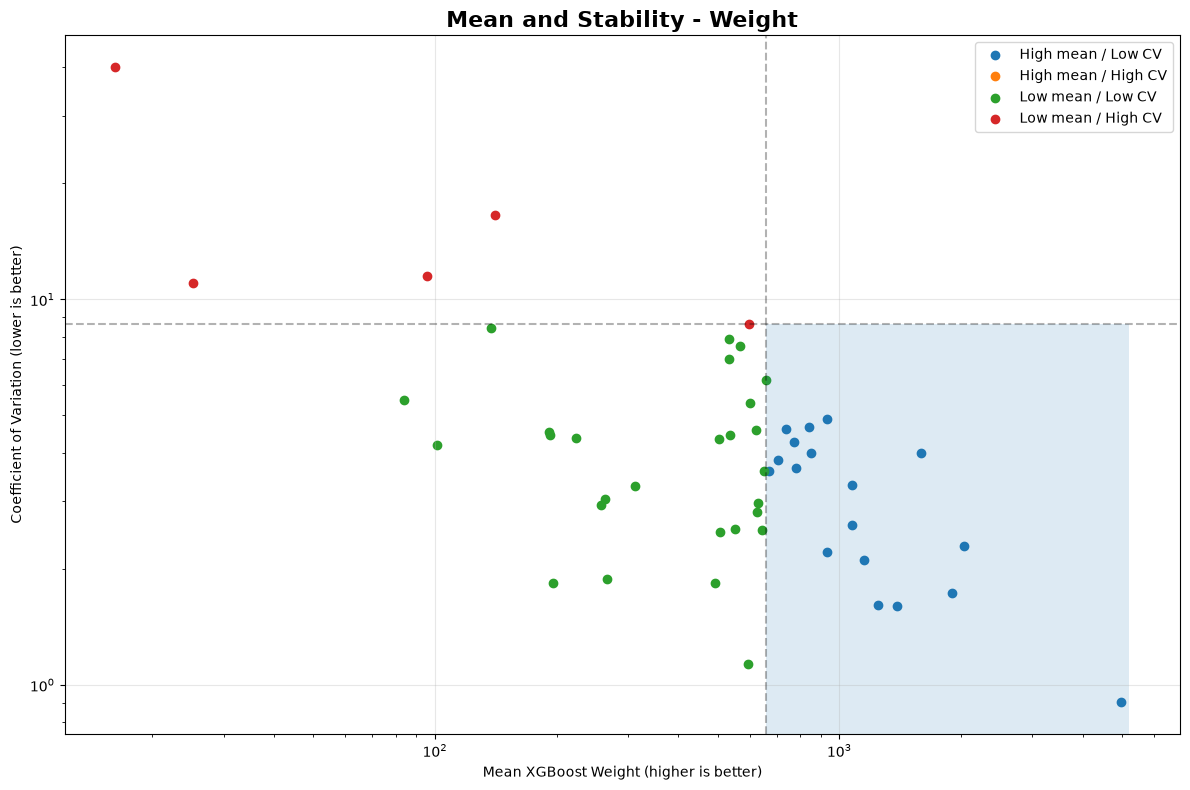

CPU times: user 526 ms, sys: 7.87 ms, total: 534 ms
Wall time: 535 ms


In [89]:
%%time

scatterPlot(
    weight_scatter,
    "Mean and Stability - Weight",
    "Mean XGBoost Weight (higher is better)",
    "Coefficient of Variation (lower is better)",
    weight_mean_threshold,
    weight_cv_threshold
)

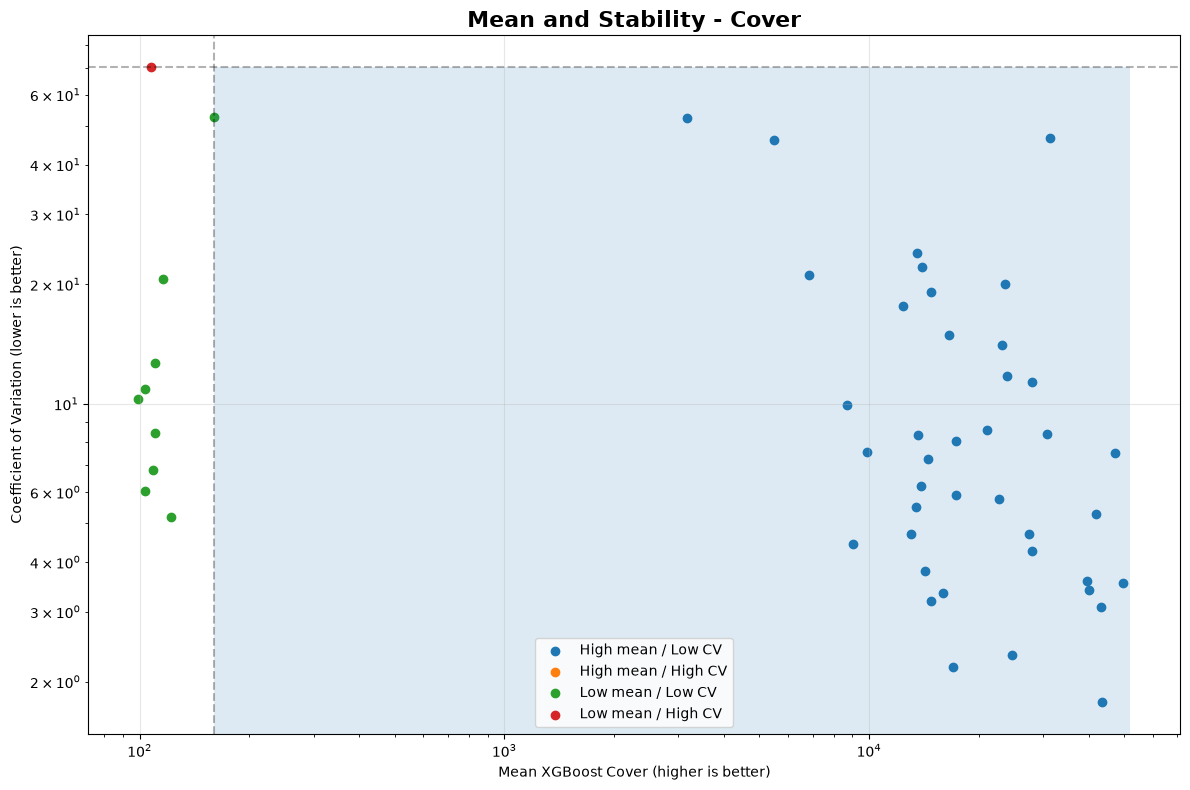

CPU times: user 723 ms, sys: 15.8 ms, total: 738 ms
Wall time: 742 ms


In [90]:
%%time

scatterPlot(
    cover_scatter,
    "Mean and Stability - Cover",
    "Mean XGBoost Cover (higher is better)",
    "Coefficient of Variation (lower is better)",
    cover_mean_threshold,
    cover_cv_threshold
)

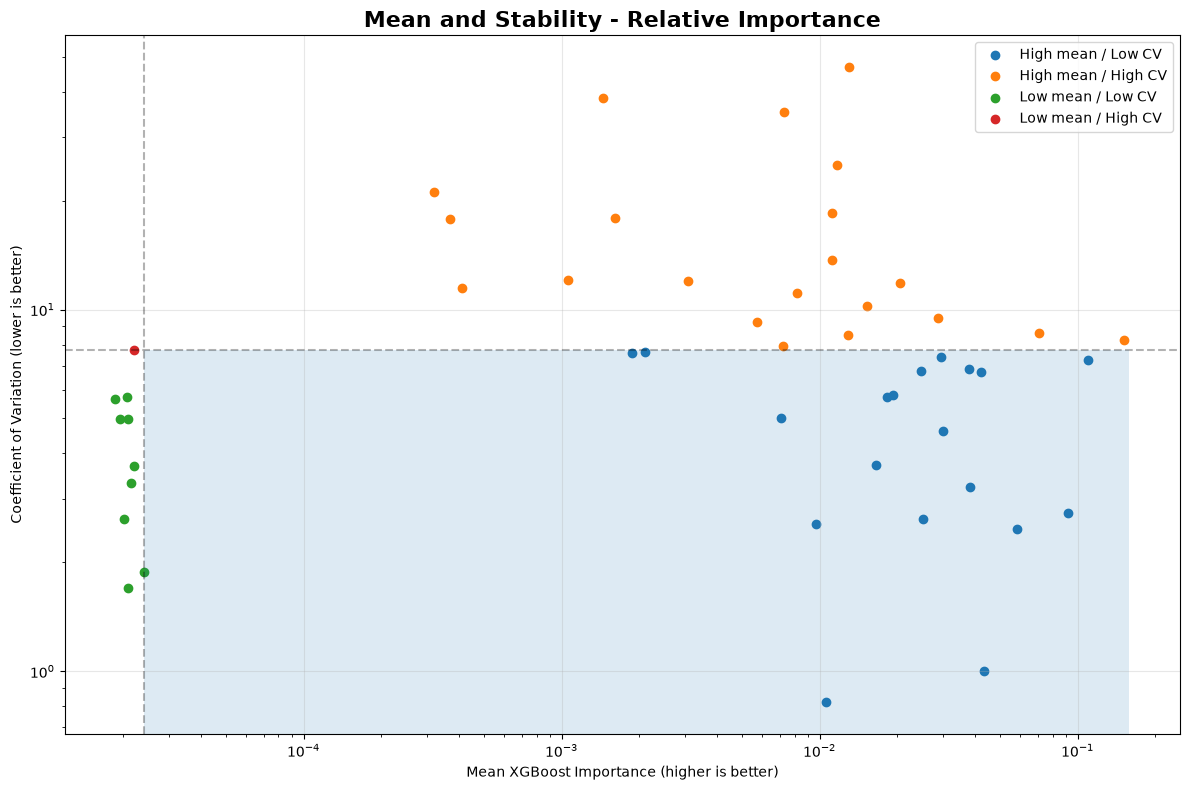

CPU times: user 626 ms, sys: 13.9 ms, total: 640 ms
Wall time: 640 ms


In [91]:
%%time

scatterPlot(
    importance_scatter,
    "Mean and Stability - Relative Importance",
    "Mean XGBoost Importance (higher is better)",
    "Coefficient of Variation (lower is better)",
    importance_mean_threshold,
    importance_cv_threshold
)

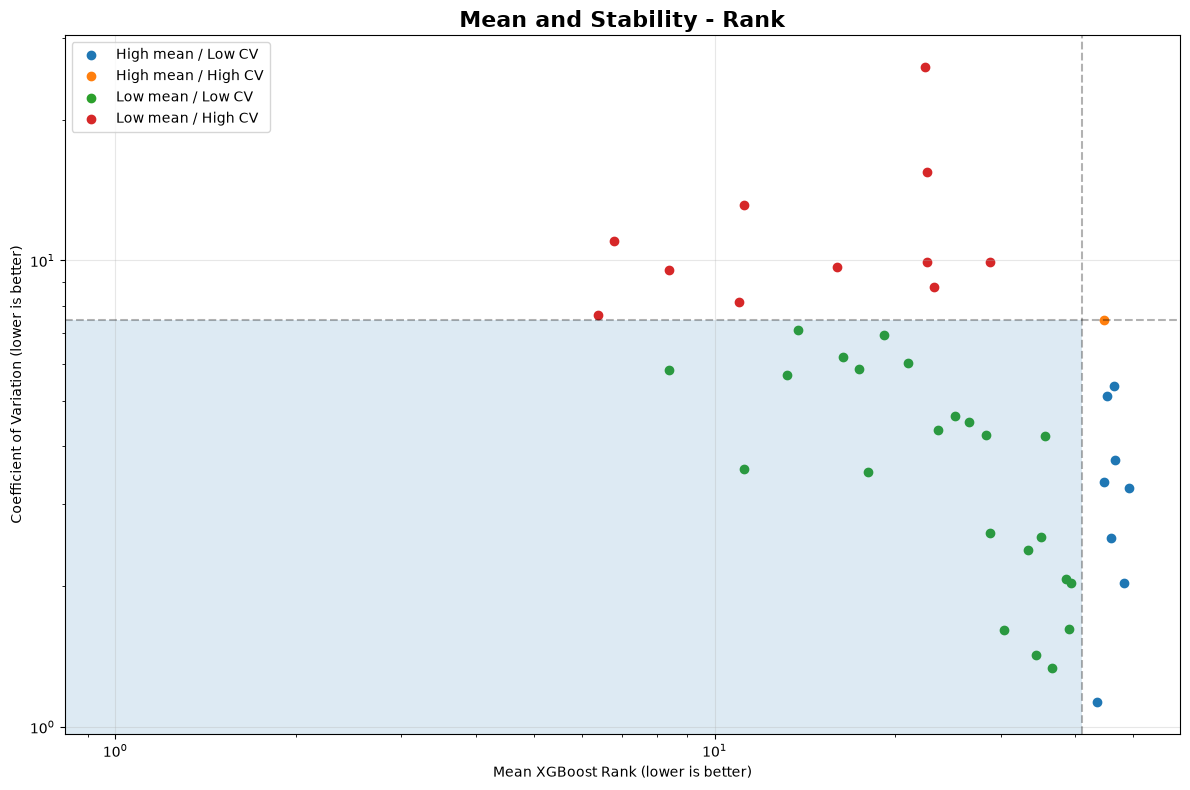

CPU times: user 460 ms, sys: 16.7 ms, total: 477 ms
Wall time: 478 ms


In [109]:
%%time

scatterPlot(
    rank_scatter,
    "Mean and Stability - Rank",
    "Mean XGBoost Rank (lower is better)",
    "Coefficient of Variation (lower is better)",
    rank_mean_threshold,
    rank_cv_threshold
)

## Exporting Descriptive Features

Parse high mean / low CV quadrant values for each parameter from scatterplots. Create a voting mechanism between them for keeping the features (favor gain, weight and cover)

In [93]:
features.drop(random_columns, axis=1, inplace=True)

In [110]:
gain_important_features = [
    feature for feature in features.columns if (gain_scatter[feature]["mean"] > gain_mean_threshold) and (gain_scatter[feature]["cv"] < gain_cv_threshold)
]
weight_important_features = [
    feature for feature in features.columns if (weight_scatter[feature]["mean"] > weight_mean_threshold) and (weight_scatter[feature]["cv"] < weight_cv_threshold)
]
cover_important_features = [
    feature for feature in features.columns if (cover_scatter[feature]["mean"] > cover_mean_threshold) and (cover_scatter[feature]["cv"] < cover_cv_threshold)
]
importance_important_features = [
    feature for feature in features.columns if (importance_scatter[feature]["mean"] > importance_mean_threshold) and (importance_scatter[feature]["cv"] < importance_cv_threshold)
]
rank_important_features = [
    feature for feature in features.columns if (rank_scatter[feature]["mean"] < rank_mean_threshold) and (rank_scatter[feature]["cv"] < rank_cv_threshold)
]

In [111]:
gain_important_features

['Flow Duration',
 'TotLen Fwd Pkts',
 'TotLen Bwd Pkts',
 'Fwd Pkt Len Std',
 'Bwd Pkt Len Std',
 'Flow IAT Min',
 'Fwd IAT Std',
 'Fwd IAT Min',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Bwd IAT Min',
 'Fwd Header Len',
 'Bwd Pkts/s',
 'Pkt Len Std',
 'FIN Flag Cnt',
 'RST Flag Cnt',
 'Init Fwd Win Byts',
 'Init Bwd Win Byts',
 'Fwd Seg Size Min']

In [112]:
weight_important_features

['Flow Duration',
 'TotLen Fwd Pkts',
 'TotLen Bwd Pkts',
 'Fwd Pkt Len Mean',
 'Fwd Pkt Len Std',
 'Bwd Pkt Len Std',
 'Flow Byts/s',
 'Flow Pkts/s',
 'Flow IAT Std',
 'Flow IAT Min',
 'Fwd IAT Mean',
 'Fwd IAT Min',
 'Fwd Header Len',
 'Bwd Pkts/s',
 'Pkt Len Std',
 'Init Fwd Win Byts',
 'Init Bwd Win Byts',
 'Fwd Seg Size Min']

In [113]:
cover_important_features

['Protocol',
 'Flow Duration',
 'Tot Fwd Pkts',
 'Tot Bwd Pkts',
 'TotLen Fwd Pkts',
 'TotLen Bwd Pkts',
 'Fwd Pkt Len Mean',
 'Fwd Pkt Len Std',
 'Bwd Pkt Len Min',
 'Bwd Pkt Len Std',
 'Flow Byts/s',
 'Flow Pkts/s',
 'Flow IAT Std',
 'Flow IAT Min',
 'Fwd IAT Mean',
 'Fwd IAT Std',
 'Fwd IAT Min',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Bwd IAT Min',
 'Fwd URG Flags',
 'Fwd Header Len',
 'Bwd Pkts/s',
 'Pkt Len Min',
 'Pkt Len Std',
 'FIN Flag Cnt',
 'SYN Flag Cnt',
 'RST Flag Cnt',
 'PSH Flag Cnt',
 'ACK Flag Cnt',
 'URG Flag Cnt',
 'Down/Up Ratio',
 'Init Fwd Win Byts',
 'Init Bwd Win Byts',
 'Fwd Act Data Pkts',
 'Fwd Seg Size Min',
 'Active Mean',
 'Active Std',
 'Idle Mean',
 'Idle Std']

In [114]:
importance_important_features

['Flow Duration',
 'TotLen Fwd Pkts',
 'TotLen Bwd Pkts',
 'Fwd Pkt Len Std',
 'Bwd Pkt Len Std',
 'Flow IAT Min',
 'Fwd IAT Std',
 'Fwd IAT Min',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Bwd IAT Min',
 'Fwd Header Len',
 'Bwd Pkts/s',
 'FIN Flag Cnt',
 'SYN Flag Cnt',
 'RST Flag Cnt',
 'Init Fwd Win Byts',
 'Init Bwd Win Byts',
 'Fwd Seg Size Min']

In [115]:
rank_important_features

['Protocol',
 'Tot Bwd Pkts',
 'TotLen Fwd Pkts',
 'Fwd Pkt Len Mean',
 'Bwd Pkt Len Min',
 'Bwd Pkt Len Std',
 'Flow IAT Std',
 'Flow IAT Min',
 'Fwd IAT Min',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Bwd IAT Min',
 'Fwd Header Len',
 'Bwd Pkts/s',
 'Pkt Len Min',
 'Pkt Len Std',
 'FIN Flag Cnt',
 'SYN Flag Cnt',
 'RST Flag Cnt',
 'PSH Flag Cnt',
 'URG Flag Cnt',
 'Down/Up Ratio',
 'Init Fwd Win Byts',
 'Init Bwd Win Byts',
 'Fwd Seg Size Min',
 'Active Mean',
 'Active Std',
 'Idle Mean',
 'Idle Std']

In [116]:
from collections import Counter

vote_counts = Counter()
for s in (gain_important_features, weight_important_features, cover_important_features, importance_important_features):
    vote_counts.update(s)

final_features = sorted(f for f, count in vote_counts.items() if count >= 3)

final_features

['Bwd IAT Mean',
 'Bwd IAT Min',
 'Bwd IAT Std',
 'Bwd Pkt Len Std',
 'Bwd Pkts/s',
 'FIN Flag Cnt',
 'Flow Duration',
 'Flow IAT Min',
 'Fwd Header Len',
 'Fwd IAT Min',
 'Fwd IAT Std',
 'Fwd Pkt Len Std',
 'Fwd Seg Size Min',
 'Init Bwd Win Byts',
 'Init Fwd Win Byts',
 'Pkt Len Std',
 'RST Flag Cnt',
 'TotLen Bwd Pkts',
 'TotLen Fwd Pkts']

In [117]:
vote_counts

Counter({'Flow Duration': 4,
         'TotLen Fwd Pkts': 4,
         'TotLen Bwd Pkts': 4,
         'Fwd Pkt Len Std': 4,
         'Bwd Pkt Len Std': 4,
         'Flow IAT Min': 4,
         'Fwd IAT Min': 4,
         'Fwd Header Len': 4,
         'Bwd Pkts/s': 4,
         'Init Fwd Win Byts': 4,
         'Init Bwd Win Byts': 4,
         'Fwd Seg Size Min': 4,
         'Fwd IAT Std': 3,
         'Bwd IAT Mean': 3,
         'Bwd IAT Std': 3,
         'Bwd IAT Min': 3,
         'Pkt Len Std': 3,
         'FIN Flag Cnt': 3,
         'RST Flag Cnt': 3,
         'Fwd Pkt Len Mean': 2,
         'Flow Byts/s': 2,
         'Flow Pkts/s': 2,
         'Flow IAT Std': 2,
         'Fwd IAT Mean': 2,
         'SYN Flag Cnt': 2,
         'Protocol': 1,
         'Tot Fwd Pkts': 1,
         'Tot Bwd Pkts': 1,
         'Bwd Pkt Len Min': 1,
         'Fwd URG Flags': 1,
         'Pkt Len Min': 1,
         'PSH Flag Cnt': 1,
         'ACK Flag Cnt': 1,
         'URG Flag Cnt': 1,
         'Down/Up Ratio':

In [118]:
print(f"Final feature count: {len(final_features)}")

Final feature count: 19


In [119]:
final_features

['Bwd IAT Mean',
 'Bwd IAT Min',
 'Bwd IAT Std',
 'Bwd Pkt Len Std',
 'Bwd Pkts/s',
 'FIN Flag Cnt',
 'Flow Duration',
 'Flow IAT Min',
 'Fwd Header Len',
 'Fwd IAT Min',
 'Fwd IAT Std',
 'Fwd Pkt Len Std',
 'Fwd Seg Size Min',
 'Init Bwd Win Byts',
 'Init Fwd Win Byts',
 'Pkt Len Std',
 'RST Flag Cnt',
 'TotLen Bwd Pkts',
 'TotLen Fwd Pkts']

In [120]:
final_features.append('Label')

In [121]:
df[final_features]

,Bwd IAT Mean,Bwd IAT Min,Bwd IAT Std,Bwd Pkt Len Std,Bwd Pkts/s,FIN Flag Cnt,Flow Duration,Flow IAT Min,Fwd Header Len,Fwd IAT Min,Fwd IAT Std,Fwd Pkt Len Std,Fwd Seg Size Min,Init Bwd Win Byts,Init Fwd Win Byts,Pkt Len Std,RST Flag Cnt,TotLen Bwd Pkts,TotLen Fwd Pkts,Label
0,8569.50000,1.0,13036.89082,655.432936,49.510203,0,141385,1.0,192,22.0,23965.32327,87.534438,20,119,8192,474.712955,1,3773.0,553.0,Benign
1,0.00000,0.0,0.00000,0.000000,3558.718861,0,281,17.0,40,281.0,0.00000,26.870058,20,0,123,21.939310,0,0.0,38.0,Benign
2,18494.57143,1.0,36356.50372,636.314186,53.605123,0,279824,1.0,232,94.0,36167.74032,129.392497,20,1047,8192,566.234209,1,10527.0,1086.0,Benign
3,0.00000,0.0,0.00000,0.000000,0.000000,0,132,132.0,40,132.0,0.00000,0.000000,20,-1,256,0.000000,0,0.0,0.0,Benign
4,21082.83333,1.0,39075.73819,611.180489,47.442485,0,274016,1.0,192,201.0,37996.56546,183.887722,20,1047,8192,497.254764,1,6141.0,1285.0,Benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10819037,0.00000,0.0,0.00000,0.000000,50000.000000,0,20,20.0,24,0.0,0.00000,0.000000,24,0,65535,0.000000,0,0.0,0.0,Infilteration
10819038,0.00000,0.0,0.00000,0.000000,9.483617,0,105445,21.0,40,105445.0,0.00000,0.000000,20,0,1024,0.000000,0,0.0,0.0,Benign
10819039,733857.00000,733857.0,0.00000,0.000000,2.725241,0,733880,22.0,64,733858.0,0.00000,0.000000,32,0,8192,0.000000,0,0.0,0.0,Benign
10819040,732708.00000,732708.0,0.00000,0.000000,2.729526,0,732728,20.0,64,732697.0,0.00000,0.000000,32,0,8192,0.000000,0,0.0,0.0,Benign


CPU times: user 2min 53s, sys: 1.6 s, total: 2min 54s
Wall time: 2min 56s


# Testing features

Fit new XGBoost model on test_df with only the selected features to test their classification performance

In [124]:
X_test = test_df[final_features].drop(['Label'], axis=1)
y_test = test_df['Label']

In [125]:
X_test

,Bwd IAT Mean,Bwd IAT Min,Bwd IAT Std,Bwd Pkt Len Std,Bwd Pkts/s,FIN Flag Cnt,Flow Duration,Flow IAT Min,Fwd Header Len,Fwd IAT Min,Fwd IAT Std,Fwd Pkt Len Std,Fwd Seg Size Min,Init Bwd Win Byts,Init Fwd Win Byts,Pkt Len Std,RST Flag Cnt,TotLen Bwd Pkts,TotLen Fwd Pkts
297465,0.000000,0.0,0.000000,0.000000,19607.843140,0,51,51.0,20,0.0,0.000000,0.000000,20,257,1024,0.000000,0,0.0,0.0
887424,0.000000,0.0,0.000000,0.000000,0.000000,0,48765,48765.0,64,48765.0,0.000000,0.000000,32,-1,225,0.000000,0,0.0,0.0
184702,231757.333300,72065.0,361470.874600,430.098604,4.804073,0,1457097,2.0,168,2.0,387073.564500,222.792023,20,62868,8192,317.762798,0,1581.0,1132.0
4550708,306928.833333,161844.0,317180.687526,430.098604,3.495470,0,2002592,51.0,172,107.0,393140.929872,222.623321,20,62872,8192,317.731274,0,1581.0,1128.0
4068450,16084.500000,12.0,28609.228167,654.362467,59.308463,0,118027,6.0,212,11.0,16715.813033,87.565150,20,62,8192,465.828901,1,3834.0,581.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1443915,0.000000,0.0,0.000000,0.000000,37037.037037,0,27,27.0,20,0.0,0.000000,0.000000,20,64209,31088,0.000000,0,0.0,0.0
8323503,58.000000,58.0,0.000000,0.000000,28.159495,0,71024,58.0,16,36699.0,0.000000,0.000000,8,-1,-1,48.747308,0,242.0,64.0
571051,69454.200000,1.0,97368.378880,710.411055,12.911056,0,464718,1.0,192,24.0,45824.303640,83.482699,20,172,8192,537.195790,0,4402.0,512.0
1366714,188886.250000,184980.0,4437.637388,167.035326,5.276466,0,947604,39.0,152,86.0,77479.356288,49.217206,20,257,8192,109.533217,0,582.0,364.0


In [126]:
y_test

297465               Benign
887424     DoS attacks-Hulk
184702               Benign
4550708              Benign
4068450              Benign
                 ...       
1443915              Benign
8323503              Benign
571051               Benign
1366714              Benign
3637500              Benign
Name: Label, Length: 2163809, dtype: str

In [137]:
y_test_encoded = le.fit_transform(y_test)

In [138]:
y_test_encoded

array([0, 8, 0, ..., 0, 0, 0], shape=(2163809,))

In [139]:
X_train_2 = train_df[final_features].drop(['Label'], axis=1)
y_train_2 = train_df['Label']
y_train_encoded = le.fit_transform(y_train_2)

In [140]:
X_train_2

,Bwd IAT Mean,Bwd IAT Min,Bwd IAT Std,Bwd Pkt Len Std,Bwd Pkts/s,FIN Flag Cnt,Flow Duration,Flow IAT Min,Fwd Header Len,Fwd IAT Min,Fwd IAT Std,Fwd Pkt Len Std,Fwd Seg Size Min,Init Bwd Win Byts,Init Fwd Win Byts,Pkt Len Std,RST Flag Cnt,TotLen Bwd Pkts,TotLen Fwd Pkts
8508731,0.000000e+00,0.0,0.000000e+00,0.000000,0.000000,0,1002405,1002405.0,80,1002405.0,0.000000e+00,0.000000,40,-1,14600,0.000000,0,0.0,0.0
6518690,0.000000e+00,0.0,0.000000e+00,0.000000,76.022503,0,13154,13154.0,8,0.0,0.000000e+00,0.000000,8,-1,-1,73.900834,0,169.0,41.0
2327515,4.712103e+05,38.0,8.157108e+05,482.000000,2.829565,0,1413645,2.0,72,2.0,3.401184e+02,11.547005,20,211,8192,339.887376,1,964.0,20.0
10413527,1.824200e+04,18242.0,0.000000e+00,239.709199,105.124836,0,19025,3.0,124,3.0,9.189561e+03,418.144712,20,32768,65535,335.146343,1,339.0,935.0
10506275,2.794806e+05,1.0,8.942939e+05,539.697804,3.876335,0,3095708,1.0,232,46.0,2.501986e+04,315.175276,20,8002,8192,440.858352,1,4427.0,2017.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4507796,4.198413e+05,202880.0,2.103825e+05,406.121705,2.548628,0,3138944,61.0,172,74.0,4.436773e+05,228.129662,20,62852,8192,312.044091,0,1581.0,1148.0
10100684,6.470000e+02,647.0,0.000000e+00,193.747258,1592.356688,0,1256,6.0,124,6.0,4.591347e+02,418.144712,20,32768,65535,330.927458,1,274.0,935.0
7639574,0.000000e+00,0.0,0.000000e+00,0.000000,0.000000,0,97232803,3999423.0,72,3999423.0,9.891067e+06,0.000000,8,-1,-1,0.000000,0,0.0,2700.0
2079101,2.340000e+02,28.0,1.967638e+02,121.500000,3933.136676,0,1017,28.0,72,151.0,1.548564e+02,85.447840,20,149,8192,93.993066,0,243.0,148.0


In [141]:
y_train_encoded

array([0, 0, 6, ..., 0, 0, 0], shape=(8655233,))

In [129]:
params_test = {
    'device': 'cuda',
    'objective': 'multi:softprob',
    'eval_metric': 'aucpr',
    
    'max_depth': 5,
    'min_child_weight': 5,
    
    'learning_rate': 0.1,
    'n_estimators': 1000,
    'tree_method': 'hist',
    
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    
    #'enable_categorical': True
}

In [142]:
model = xgb.XGBClassifier(**params_test)

In [143]:
%%time

model.fit(X_train_2, y_train_encoded)

CPU times: user 17min 43s, sys: 16.1 s, total: 17min 59s
Wall time: 17min 47s


,"objective objective: typing.Union[str, xgboost.objective.Objective, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklea

In [147]:
%%time

y_preds = model.predict(X_test)

CPU times: user 24.8 s, sys: 71.1 ms, total: 24.9 s
Wall time: 24.3 s


In [148]:
print(classification_report(y_test_encoded, y_preds))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99   1898640
           1       1.00      1.00      1.00     28907
           2       0.90      0.62      0.73       111
           3       0.85      0.76      0.80        45
           4       1.00      1.00      1.00     39772
           5       0.86      0.90      0.88       346
           6       1.00      1.00      1.00    115073
           7       1.00      1.00      1.00      8281
           8       1.00      1.00      1.00     29040
           9       0.11      0.09      0.10        11
          10       0.99      0.92      0.95      1982
          11       0.10      0.10      0.10        10
          12       0.55      0.04      0.07     22764
          13       0.86      0.71      0.77        17
          14       1.00      1.00      1.00     18810

    accuracy                           0.99   2163809
   macro avg       0.81      0.74      0.76   2163809
weighted avg       0.98   

In [162]:
def confusionMatrixPlot(title, x_label, y_label, y_test, y_pred):
    """Plot confusion matrix for XGBoost model trained on selected features only"""
    cm = confusion_matrix(y_test, y_pred)

    fig, ax = plt.subplots(figsize=(10, 10))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=np.unique(y_test)
    )

    disp.plot(
        ax=ax,
        cmap="Blues",
        values_format="d",
        colorbar=False
    )

    plt.xticks(rotation=90)
    plt.title(
        f"{title}",
        fontsize = 16,
        fontweight="bold"
    )

    ax.set_xlabel(
        f"{x_label}",
        fontsize=12
    )
    ax.set_ylabel(
        f"{y_label}",
        fontsize=12
    )

    plt.tight_layout()
    plt.show()

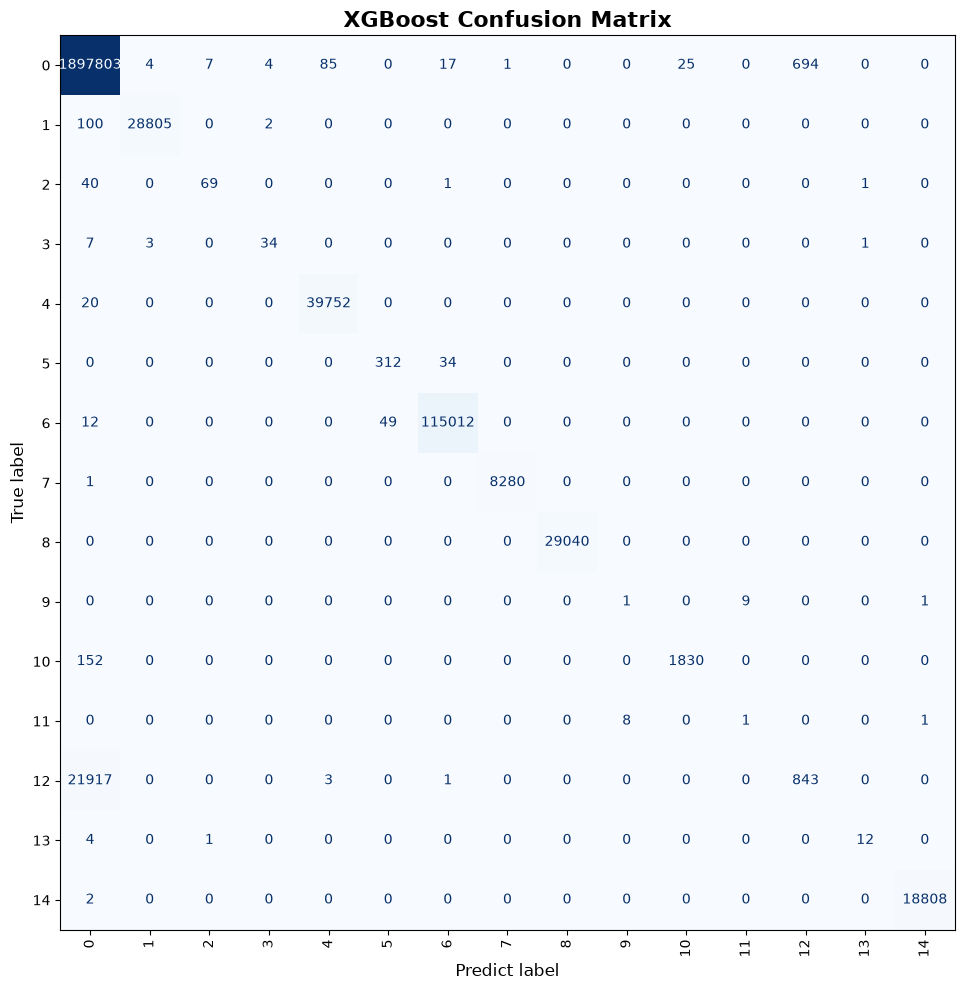

CPU times: user 1.01 s, sys: 8.76 ms, total: 1.02 s
Wall time: 1.03 s


In [164]:
%%time

confusionMatrixPlot("XGBoost Confusion Matrix", "Predict label", "True label", y_test_encoded, y_preds)

# Save Dataset With Important Features Only

In [157]:
%%time

df[final_features]

CPU times: user 159 ms, sys: 84.2 ms, total: 243 ms
Wall time: 247 ms


,Bwd IAT Mean,Bwd IAT Min,Bwd IAT Std,Bwd Pkt Len Std,Bwd Pkts/s,FIN Flag Cnt,Flow Duration,Flow IAT Min,Fwd Header Len,Fwd IAT Min,Fwd IAT Std,Fwd Pkt Len Std,Fwd Seg Size Min,Init Bwd Win Byts,Init Fwd Win Byts,Pkt Len Std,RST Flag Cnt,TotLen Bwd Pkts,TotLen Fwd Pkts,Label
0,8569.50000,1.0,13036.89082,655.432936,49.510203,0,141385,1.0,192,22.0,23965.32327,87.534438,20,119,8192,474.712955,1,3773.0,553.0,Benign
1,0.00000,0.0,0.00000,0.000000,3558.718861,0,281,17.0,40,281.0,0.00000,26.870058,20,0,123,21.939310,0,0.0,38.0,Benign
2,18494.57143,1.0,36356.50372,636.314186,53.605123,0,279824,1.0,232,94.0,36167.74032,129.392497,20,1047,8192,566.234209,1,10527.0,1086.0,Benign
3,0.00000,0.0,0.00000,0.000000,0.000000,0,132,132.0,40,132.0,0.00000,0.000000,20,-1,256,0.000000,0,0.0,0.0,Benign
4,21082.83333,1.0,39075.73819,611.180489,47.442485,0,274016,1.0,192,201.0,37996.56546,183.887722,20,1047,8192,497.254764,1,6141.0,1285.0,Benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10819037,0.00000,0.0,0.00000,0.000000,50000.000000,0,20,20.0,24,0.0,0.00000,0.000000,24,0,65535,0.000000,0,0.0,0.0,Infilteration
10819038,0.00000,0.0,0.00000,0.000000,9.483617,0,105445,21.0,40,105445.0,0.00000,0.000000,20,0,1024,0.000000,0,0.0,0.0,Benign
10819039,733857.00000,733857.0,0.00000,0.000000,2.725241,0,733880,22.0,64,733858.0,0.00000,0.000000,32,0,8192,0.000000,0,0.0,0.0,Benign
10819040,732708.00000,732708.0,0.00000,0.000000,2.729526,0,732728,20.0,64,732697.0,0.00000,0.000000,32,0,8192,0.000000,0,0.0,0.0,Benign


In [158]:
%%time

df[final_features].to_csv("data/final.csv", encoding="utf-8", index=False)

CPU times: user 2min 7s, sys: 2.36 s, total: 2min 10s
Wall time: 2min 11s
